# 2000 Lineage Experiment: LARRY source-target clone-sharing pipeline

This notebook analyzes within-day source-target clone-sharing relationships from LARRY metadata.

Important interpretation:
- D4, D7, and D12 are independent experiments.
- The merged metadata table is only used for convenience.
- All source-target analyses are performed within each day separately.
- No cross-day trajectory or differentiation path is inferred.


## 0. Setup

In [1]:
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import networkx as nx

from statsmodels.stats.multitest import multipletests
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch

project_dir = Path("/mnt/yiming/nfs_share/projects/hypoblast")
os.chdir(project_dir)
sys.path.append(str(project_dir))

processed_dir = Path("results/processed")
table_dir = Path("results/tables/2000_lineage_exp")
fig_dir = Path("results/figures/2000_lineage_exp")

table_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

print(Path.cwd())

/mnt/yiming/nfs_share/projects/hypoblast


## 1. Export lightweight metadata from h5ad

In [2]:
adata_paths = {
    "D4": processed_dir / "larry_d4_revised_labels_subcluster.h5ad",
    "D7": processed_dir / "larry_d7_revised_labels.h5ad",
    "D12": processed_dir / "larry_d12_revised_labels.h5ad",
}

for day, path in adata_paths.items():
    print(day, path, path.exists())

D4 results/processed/larry_d4_revised_labels_subcluster.h5ad True
D7 results/processed/larry_d7_revised_labels.h5ad True
D12 results/processed/larry_d12_revised_labels.h5ad True


In [3]:
celltype_key_by_day = {
    "D4": "CellType_short",
    # "D4": "CellType_short_sub",  # use this if you want D4 subcluster annotation
    "D7": "CellType_short",
    "D12": "CellType_short",
}

clone_key_by_day = {
    "D4": "larry_clone",
    "D7": "larry_clone",
    "D12": "larry_clone",
}

barcode_key_by_day = {
    "D4": "larry_barcode",
    "D7": "larry_barcode",
    "D12": "larry_barcode",
}

In [4]:
def export_larry_metadata(
    adata,
    day,
    celltype_key,
    clone_key,
    barcode_key=None,
    output_path=None,
    extra_cols=None,
):
    """
    Export lightweight metadata for LARRY clone-sharing analysis.

    Output standard columns:
        cell_id
        day
        celltype
        clone_id
        larry_barcode, optional
        extra columns, optional
    """

    obs = adata.obs.copy()

    required = [celltype_key, clone_key]
    if barcode_key is not None:
        required.append(barcode_key)

    missing = [x for x in required if x not in obs.columns]
    if len(missing) > 0:
        raise KeyError(f"Missing columns: {missing}")

    keep_cols = [celltype_key, clone_key]

    if barcode_key is not None and barcode_key in obs.columns:
        keep_cols.append(barcode_key)

    if extra_cols is not None:
        for col in extra_cols:
            if col in obs.columns and col not in keep_cols:
                keep_cols.append(col)

    meta = obs[keep_cols].copy()
    meta.insert(0, "cell_id", obs.index.astype(str))
    meta.insert(1, "day", day)

    rename_dict = {
        celltype_key: "celltype",
        clone_key: "clone_id",
    }
    if barcode_key is not None and barcode_key in meta.columns:
        rename_dict[barcode_key] = "larry_barcode"

    meta = meta.rename(columns=rename_dict)

    meta["celltype"] = meta["celltype"].astype("string")
    meta["clone_id"] = meta["clone_id"].astype("string")

    if "larry_barcode" in meta.columns:
        meta["larry_barcode"] = meta["larry_barcode"].astype("string")

    invalid_clone_values = [
        "", "nan", "NaN", "NA", "N/A", "None", "none",
        "Unassigned", "unassigned", "No_clone", "no_clone",
    ]

    meta["clone_id"] = meta["clone_id"].replace(invalid_clone_values, pd.NA)

    if output_path is not None:
        meta.to_csv(output_path, index=False)
        print(f"Saved: {output_path}")

    print("=" * 80)
    print(day)
    print("shape:", meta.shape)
    print("n celltypes:", meta["celltype"].nunique(dropna=True))
    print("n clones:", meta["clone_id"].nunique(dropna=True))
    print("n cells without clone:", meta["clone_id"].isna().sum())
    print("\ncelltype counts:")
    print(meta["celltype"].value_counts(dropna=False))

    return meta

In [5]:
metadata_by_day = {}

for day, path in adata_paths.items():
    print("=" * 100)
    print(day)

    adata = sc.read_h5ad(path)

    celltype_key = celltype_key_by_day[day]
    clone_key = clone_key_by_day[day]
    barcode_key = barcode_key_by_day[day]

    extra_cols = [
        "CellType_short",
        "CellType_short_sub",
        "CellType_man",
        "larry_barcode",
        "larry_clone",
        "sample",
        "batch",
    ]

    out_path = table_dir / f"larry_{day.lower()}_metadata.csv"

    meta = export_larry_metadata(
        adata=adata,
        day=day,
        celltype_key=celltype_key,
        clone_key=clone_key,
        barcode_key=barcode_key,
        output_path=out_path,
        extra_cols=extra_cols,
    )

    metadata_by_day[day] = meta

D4


Saved: results/tables/2000_lineage_exp/larry_d4_metadata.csv
D4
shape: (4618, 7)
n celltypes: 8
n clones: 2626
n cells without clone: 0

celltype counts:
celltype
Epi          1453
Adv Mes      1309
HE            494
Trans ExM     440
PGC           269
Nasc Mes      253
Amn           251
Endoderm      149
Name: count, dtype: Int64
D7
Saved: results/tables/2000_lineage_exp/larry_d7_metadata.csv
D7
shape: (3824, 5)
n celltypes: 11
n clones: 1682
n cells without clone: 0

celltype counts:
celltype
Adv Mes      1600
Amn           655
Trans ExM     519
HE            382
EMP           284
Epi           109
PS             87
PGC            70
Endoderm       46
Ery            40
Emerg Mes      32
Name: count, dtype: Int64
D12
Saved: results/tables/2000_lineage_exp/larry_d12_metadata.csv
D12
shape: (9010, 6)
n celltypes: 10
n clones: 1838
n cells without clone: 0

celltype counts:
celltype
Ery        2689
Adv Mes    2303
Amn        1393
Mk         1289
YS Mes      614
EMP         430
Vein      

In [6]:
# Merge metadata only for convenience.
# All later analyses are grouped by day and do not infer cross-day relationships.
all_meta = pd.concat(metadata_by_day.values(), axis=0, ignore_index=True)

all_meta_path = table_dir / "larry_all_metadata.csv"
all_meta.to_csv(all_meta_path, index=False)

print("Saved:", all_meta_path)
print(all_meta.shape)
all_meta.head()

Saved: results/tables/2000_lineage_exp/larry_all_metadata.csv
(17452, 7)


,cell_id,day,celltype,clone_id,larry_barcode,CellType_short_sub,CellType_man
0,AAACCCACAAGACCTT-1,D4,Adv Mes,clone_1,GGTTTGAGCACAGATTACAATAGACCCGGTCTCGAGACAA,Adv Mes,Adv.Mes
1,AAACCCAGTCAGGTAG-1,D4,Amn,clone_2,TGACTGAACTCATTCAACAAGGGAAAGAGTGGTAAGCGAA,Amn,Amn
2,AAACCCAGTCGTCAGC-1,D4,Epi,clone_3,TAACTGATACCAAATAACGGCTGATGAGGTCGCAAGTTAT,Epi,Epi
3,AAACCCATCAAACCTG-1,D4,Epi,clone_4,CCGTTGGCTTCATCGCACTGCCGAACCCGTCGATAGCAAG,Epi,Epi
4,AAACCCATCAGGAACG-1,D4,Epi,clone_5,AGTATGATAACAGAATACTCAGGAGTCCGTTGGTAGCGGA-CACGT...,Epi,Epi


## 2. Metadata QC

In [7]:
meta = pd.read_csv(table_dir / "larry_all_metadata.csv")

print(meta.shape)
meta.head()

(17452, 7)


,cell_id,day,celltype,clone_id,larry_barcode,CellType_short_sub,CellType_man
0,AAACCCACAAGACCTT-1,D4,Adv Mes,clone_1,GGTTTGAGCACAGATTACAATAGACCCGGTCTCGAGACAA,Adv Mes,Adv.Mes
1,AAACCCAGTCAGGTAG-1,D4,Amn,clone_2,TGACTGAACTCATTCAACAAGGGAAAGAGTGGTAAGCGAA,Amn,Amn
2,AAACCCAGTCGTCAGC-1,D4,Epi,clone_3,TAACTGATACCAAATAACGGCTGATGAGGTCGCAAGTTAT,Epi,Epi
3,AAACCCATCAAACCTG-1,D4,Epi,clone_4,CCGTTGGCTTCATCGCACTGCCGAACCCGTCGATAGCAAG,Epi,Epi
4,AAACCCATCAGGAACG-1,D4,Epi,clone_5,AGTATGATAACAGAATACTCAGGAGTCCGTTGGTAGCGGA-CACGT...,Epi,Epi


In [8]:
for day, df in meta.groupby("day"):
    print("=" * 100)
    print(day)
    print("n cells:", df.shape[0])
    print("n celltypes:", df["celltype"].nunique(dropna=True))
    print("n clones:", df["clone_id"].nunique(dropna=True))
    print("n cells without clone:", df["clone_id"].isna().sum())

    print("\ncelltype counts:")
    print(df["celltype"].value_counts())

    print("\nclone size summary:")
    clone_size = df["clone_id"].dropna().value_counts()
    print(clone_size.describe())

    print("\ntop clone sizes:")
    print(clone_size.head(10))

D12
n cells: 9010
n celltypes: 10
n clones: 1838
n cells without clone: 0

celltype counts:
celltype
Ery        2689
Adv Mes    2303
Amn        1393
Mk         1289
YS Mes      614
EMP         430
Vein        126
Art          76
PGC          57
Gran         33
Name: count, dtype: int64

clone size summary:
count    1838.000000
mean        4.902067
std        19.623655
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max       426.000000
Name: count, dtype: float64

top clone sizes:
clone_id
clone_7      426
clone_53     380
clone_27     305
clone_11     289
clone_65     233
clone_37     143
clone_128    134
clone_16     102
clone_14      98
clone_38      97
Name: count, dtype: int64
D4
n cells: 4618
n celltypes: 8
n clones: 2626
n cells without clone: 0

celltype counts:
celltype
Epi          1453
Adv Mes      1309
HE            494
Trans ExM     440
PGC           269
Nasc Mes      253
Amn           251
Endoderm      149
Name: count, dtype: int64

clo

In [9]:
def summarize_celltype_clone_info(meta_df):
    rows = []

    for (day, celltype), sub in meta_df.dropna(subset=["clone_id"]).groupby(["day", "celltype"]):
        clone_size = sub["clone_id"].value_counts()

        rows.append({
            "day": day,
            "celltype": celltype,
            "n_cells": sub.shape[0],
            "n_clones": sub["clone_id"].nunique(dropna=True),
            "median_cells_per_clone": clone_size.median(),
            "mean_cells_per_clone": clone_size.mean(),
            "max_cells_per_clone": clone_size.max(),
        })

    out = pd.DataFrame(rows)
    out = out.sort_values(["day", "n_cells"], ascending=[True, False])
    return out


celltype_clone_summary = summarize_celltype_clone_info(meta)

celltype_clone_summary.to_csv(
    table_dir / "larry_celltype_clone_summary.csv",
    index=False,
)

celltype_clone_summary

,day,celltype,n_cells,n_clones,median_cells_per_clone,mean_cells_per_clone,max_cells_per_clone
4,D12,Ery,2689,293,1.0,9.177474,233
0,D12,Adv Mes,2303,892,1.0,2.581839,33
1,D12,Amn,1393,659,1.0,2.113809,30
6,D12,Mk,1289,179,1.0,7.201117,140
9,D12,YS Mes,614,240,1.0,2.558333,27
3,D12,EMP,430,86,2.0,5.000000,63
8,D12,Vein,126,106,1.0,1.188679,3
2,D12,Art,76,49,1.0,1.551020,9
7,D12,PGC,57,49,1.0,1.163265,3
5,D12,Gran,33,16,1.0,2.062500,9


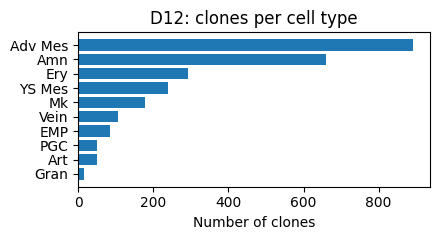

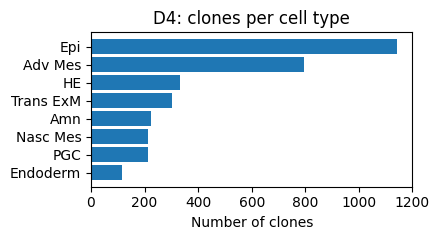

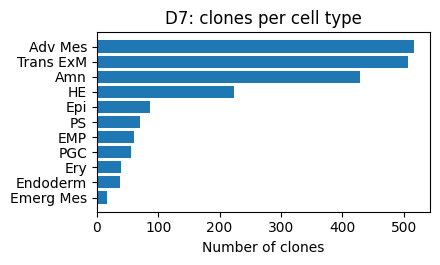

In [10]:
for day in sorted(meta["day"].unique()):
    df_day = celltype_clone_summary[celltype_clone_summary["day"] == day].copy()
    df_day = df_day.sort_values("n_clones", ascending=True)

    fig, ax = plt.subplots(figsize=(4.5, max(2.5, 0.25 * df_day.shape[0])))

    ax.barh(df_day["celltype"], df_day["n_clones"])
    ax.set_xlabel("Number of clones")
    ax.set_ylabel("")
    ax.set_title(f"{day}: clones per cell type")

    fig.tight_layout()
    fig.savefig(
        fig_dir / f"{day.lower()}_n_clones_per_celltype.pdf",
        bbox_inches="tight",
        facecolor="white",
    )
    plt.show()

## 3. Compute source-target clone-sharing relationship table

In [11]:
def compute_source_target_from_metadata(
    meta_df,
    source_celltypes=None,
    target_celltypes=None,
    day_key="day",
    celltype_key="celltype",
    clone_key="clone_id",
    min_cells_per_type=10,
    min_clones_per_type=5,
    remove_self_pairs=True,
    n_perm=1000,
    random_state=0,
):
    """
    Compute source-target clone-sharing relationship from lightweight metadata.
    Analyses are performed independently within each day.
    """

    rng = np.random.default_rng(random_state)

    df_all = meta_df.copy()
    df_all = df_all.dropna(subset=[day_key, celltype_key, clone_key]).copy()

    df_all[celltype_key] = df_all[celltype_key].astype(str)
    df_all[clone_key] = df_all[clone_key].astype(str)
    df_all[day_key] = df_all[day_key].astype(str)

    invalid_clone_values = {
        "", "nan", "NaN", "NA", "N/A", "None", "none",
        "Unassigned", "unassigned", "No_clone", "no_clone",
    }
    df_all = df_all[~df_all[clone_key].isin(invalid_clone_values)].copy()

    all_results = []

    for day, df in df_all.groupby(day_key):
        print("=" * 80)
        print(f"Computing {day}")
        print("n cells:", df.shape[0])
        print("n clones:", df[clone_key].nunique())

        available_celltypes = sorted(df[celltype_key].unique())

        if source_celltypes is None:
            sources = available_celltypes
        elif isinstance(source_celltypes, dict):
            sources = [x for x in source_celltypes.get(day, []) if x in available_celltypes]
        else:
            sources = [x for x in source_celltypes if x in available_celltypes]

        if target_celltypes is None:
            targets = available_celltypes
        elif isinstance(target_celltypes, dict):
            targets = [x for x in target_celltypes.get(day, []) if x in available_celltypes]
        else:
            targets = [x for x in target_celltypes if x in available_celltypes]

        cell_counts = df.groupby(celltype_key).size().to_dict()
        clone_sets = (
            df.groupby(celltype_key)[clone_key]
            .apply(lambda x: set(x.unique()))
            .to_dict()
        )
        clone_counts = {k: len(v) for k, v in clone_sets.items()}

        sources = [
            x for x in sources
            if cell_counts.get(x, 0) >= min_cells_per_type
            and clone_counts.get(x, 0) >= min_clones_per_type
        ]

        targets = [
            x for x in targets
            if cell_counts.get(x, 0) >= min_cells_per_type
            and clone_counts.get(x, 0) >= min_clones_per_type
        ]

        print("sources:", sources)
        print("targets:", targets)

        rows = []
        pair_list = []

        for source in sources:
            for target in targets:
                if remove_self_pairs and source == target:
                    continue

                source_clones = clone_sets[source]
                target_clones = clone_sets[target]

                n_source_cells = cell_counts[source]
                n_target_cells = cell_counts[target]
                n_source_clones = len(source_clones)
                n_target_clones = len(target_clones)
                n_shared_clones = len(source_clones & target_clones)

                source_to_target_fraction = (
                    n_shared_clones / n_source_clones
                    if n_source_clones > 0 else np.nan
                )

                target_from_source_fraction = (
                    n_shared_clones / n_target_clones
                    if n_target_clones > 0 else np.nan
                )

                rows.append({
                    "day": day,
                    "source": source,
                    "target": target,
                    "n_source_cells": n_source_cells,
                    "n_target_cells": n_target_cells,
                    "n_source_clones": n_source_clones,
                    "n_target_clones": n_target_clones,
                    "n_shared_clones": n_shared_clones,
                    "source_to_target_fraction": source_to_target_fraction,
                    "target_from_source_fraction": target_from_source_fraction,
                })

                pair_list.append((source, target))

        result = pd.DataFrame(rows)

        if result.shape[0] == 0:
            print(f"No valid source-target pairs for {day}")
            continue

        original_labels = df[celltype_key].to_numpy()
        clone_values = df[clone_key].to_numpy()

        perm_shared = np.zeros((n_perm, len(pair_list)), dtype=float)

        for i in range(n_perm):
            perm_labels = rng.permutation(original_labels)

            perm_df = pd.DataFrame({
                celltype_key: perm_labels,
                clone_key: clone_values,
            })

            perm_clone_sets = (
                perm_df.groupby(celltype_key)[clone_key]
                .apply(lambda x: set(x.unique()))
                .to_dict()
            )

            for j, (source, target) in enumerate(pair_list):
                source_set = perm_clone_sets.get(source, set())
                target_set = perm_clone_sets.get(target, set())
                perm_shared[i, j] = len(source_set & target_set)

        obs_shared = result["n_shared_clones"].to_numpy(dtype=float)
        expected = perm_shared.mean(axis=0)
        perm_std = perm_shared.std(axis=0, ddof=1)

        zscore = np.divide(
            obs_shared - expected,
            perm_std,
            out=np.full_like(obs_shared, np.nan, dtype=float),
            where=perm_std > 0,
        )

        empirical_p = (
            (perm_shared >= obs_shared[None, :]).sum(axis=0) + 1
        ) / (n_perm + 1)

        fdr = multipletests(empirical_p, method="fdr_bh")[1]

        result["expected_shared_clones"] = expected
        result["log2_obs_over_exp"] = np.log2(
            (result["n_shared_clones"].to_numpy(dtype=float) + 1e-9)
            / (result["expected_shared_clones"].to_numpy(dtype=float) + 1e-9)
        )
        result["zscore"] = zscore
        result["empirical_p"] = empirical_p
        result["fdr"] = fdr

        result = result[
            [
                "day",
                "source",
                "target",
                "n_source_cells",
                "n_target_cells",
                "n_source_clones",
                "n_target_clones",
                "n_shared_clones",
                "source_to_target_fraction",
                "target_from_source_fraction",
                "expected_shared_clones",
                "log2_obs_over_exp",
                "zscore",
                "empirical_p",
                "fdr",
            ]
        ]

        all_results.append(result)

    if len(all_results) == 0:
        return pd.DataFrame()

    out = pd.concat(all_results, axis=0, ignore_index=True)

    out = out.sort_values(
        ["day", "empirical_p", "log2_obs_over_exp"],
        ascending=[True, True, False],
    ).reset_index(drop=True)

    return out

In [12]:
meta = pd.read_csv(table_dir / "larry_all_metadata.csv")

for day, df in meta.groupby("day"):
    print("=" * 80)
    print(day)
    print(sorted(df["celltype"].dropna().unique()))

D12
['Adv Mes', 'Amn', 'Art', 'EMP', 'Ery', 'Gran', 'Mk', 'PGC', 'Vein', 'YS Mes']
D4
['Adv Mes', 'Amn', 'Endoderm', 'Epi', 'HE', 'Nasc Mes', 'PGC', 'Trans ExM']
D7
['Adv Mes', 'Amn', 'EMP', 'Emerg Mes', 'Endoderm', 'Epi', 'Ery', 'HE', 'PGC', 'PS', 'Trans ExM']


In [13]:
source_celltypes = [
    # epithelial / early populations
    "Epi",
    "PS",
    "Amn",
    "PGC",

    # endoderm / mesoderm / ExM
    "Endoderm",
    "Nasc Mes",
    "Emerg Mes",
    "Trans ExM",
    "Adv Mes",
    "YS Mes",

    # endothelial
    "HE",
    "Art",
    "Vein",

    # blood
    "EMP",
    "Ery",
    "Mk",
    "Gran",
]

target_celltypes = [
    "Epi",
    "PS",
    "Amn",
    "PGC",
    "Endoderm",
    "Nasc Mes",
    "Emerg Mes",
    "Trans ExM",
    "Adv Mes",
    "YS Mes",
    "HE",
    "Art",
    "Vein",
    "EMP",
    "Ery",
    "Mk",
    "Gran",
]

source_order = source_celltypes
target_order = target_celltypes
celltype_order = source_celltypes

In [14]:
# First test with fewer permutations if needed.
source_target_df_test = compute_source_target_from_metadata(
    meta_df=meta,
    source_celltypes=source_celltypes,
    target_celltypes=target_celltypes,
    day_key="day",
    celltype_key="celltype",
    clone_key="clone_id",
    min_cells_per_type=10,
    min_clones_per_type=5,
    remove_self_pairs=True,
    n_perm=100,
    random_state=0,
)

source_target_df_test.head(20)

Computing D12
n cells: 9010
n clones: 1838
sources: ['Amn', 'PGC', 'Adv Mes', 'YS Mes', 'Art', 'Vein', 'EMP', 'Ery', 'Mk', 'Gran']
targets: ['Amn', 'PGC', 'Adv Mes', 'YS Mes', 'Art', 'Vein', 'EMP', 'Ery', 'Mk', 'Gran']
Computing D4
n cells: 4618
n clones: 2626
sources: ['Epi', 'Amn', 'PGC', 'Endoderm', 'Nasc Mes', 'Trans ExM', 'Adv Mes', 'HE']
targets: ['Epi', 'Amn', 'PGC', 'Endoderm', 'Nasc Mes', 'Trans ExM', 'Adv Mes', 'HE']


Computing D7
n cells: 3824
n clones: 1682
sources: ['Epi', 'PS', 'Amn', 'PGC', 'Endoderm', 'Emerg Mes', 'Trans ExM', 'Adv Mes', 'HE', 'EMP', 'Ery']
targets: ['Epi', 'PS', 'Amn', 'PGC', 'Endoderm', 'Emerg Mes', 'Trans ExM', 'Adv Mes', 'HE', 'EMP', 'Ery']


,day,source,target,n_source_cells,n_target_cells,n_source_clones,n_target_clones,n_shared_clones,source_to_target_fraction,target_from_source_fraction,expected_shared_clones,log2_obs_over_exp,zscore,empirical_p,fdr
0,D12,Adv Mes,Vein,2303,126,892,106,71,0.079596,0.669811,66.29,0.099028,0.827335,0.267327,1.0
1,D12,Vein,Adv Mes,126,2303,106,892,71,0.669811,0.079596,66.29,0.099028,0.827335,0.267327,1.0
2,D12,EMP,Gran,430,33,86,16,12,0.139535,0.750000,14.55,-0.277985,-1.035168,0.910891,1.0
3,D12,Gran,EMP,33,430,16,86,12,0.750000,0.139535,14.55,-0.277985,-1.035168,0.910891,1.0
4,D12,YS Mes,Art,614,76,240,49,26,0.108333,0.530612,31.85,-0.292782,-1.613900,0.960396,1.0
5,D12,Art,YS Mes,76,614,49,240,26,0.530612,0.108333,31.85,-0.292782,-1.613900,0.960396,1.0
6,D12,Adv Mes,Art,2303,76,892,49,36,0.040359,0.734694,44.71,-0.312601,-2.329030,0.990099,1.0
7,D12,Art,Adv Mes,76,2303,49,892,36,0.734694,0.040359,44.71,-0.312601,-2.329030,0.990099,1.0
8,D12,Adv Mes,YS Mes,2303,614,892,240,141,0.158072,0.587500,199.89,-0.503511,-7.441674,1.000000,1.0
9,D12,YS Mes,Adv Mes,614,2303,240,892,141,0.587500,0.158072,199.89,-0.503511,-7.441674,1.000000,1.0


In [15]:
# Formal run.
source_target_df = compute_source_target_from_metadata(
    meta_df=meta,
    source_celltypes=source_celltypes,
    target_celltypes=target_celltypes,
    day_key="day",
    celltype_key="celltype",
    clone_key="clone_id",
    min_cells_per_type=10,
    min_clones_per_type=5,
    remove_self_pairs=True,
    n_perm=1000,
    random_state=0,
)

out_path = table_dir / "larry_source_target_relationship.csv"
source_target_df.to_csv(out_path, index=False)

print("Saved:", out_path)
source_target_df.head(20)

Computing D12
n cells: 9010
n clones: 1838
sources: ['Amn', 'PGC', 'Adv Mes', 'YS Mes', 'Art', 'Vein', 'EMP', 'Ery', 'Mk', 'Gran']
targets: ['Amn', 'PGC', 'Adv Mes', 'YS Mes', 'Art', 'Vein', 'EMP', 'Ery', 'Mk', 'Gran']


Computing D4
n cells: 4618
n clones: 2626
sources: ['Epi', 'Amn', 'PGC', 'Endoderm', 'Nasc Mes', 'Trans ExM', 'Adv Mes', 'HE']
targets: ['Epi', 'Amn', 'PGC', 'Endoderm', 'Nasc Mes', 'Trans ExM', 'Adv Mes', 'HE']
Computing D7
n cells: 3824
n clones: 1682
sources: ['Epi', 'PS', 'Amn', 'PGC', 'Endoderm', 'Emerg Mes', 'Trans ExM', 'Adv Mes', 'HE', 'EMP', 'Ery']
targets: ['Epi', 'PS', 'Amn', 'PGC', 'Endoderm', 'Emerg Mes', 'Trans ExM', 'Adv Mes', 'HE', 'EMP', 'Ery']
Saved: results/tables/2000_lineage_exp/larry_source_target_relationship.csv


,day,source,target,n_source_cells,n_target_cells,n_source_clones,n_target_clones,n_shared_clones,source_to_target_fraction,target_from_source_fraction,expected_shared_clones,log2_obs_over_exp,zscore,empirical_p,fdr
0,D12,Adv Mes,Vein,2303,126,892,106,71,0.079596,0.669811,66.185,0.101315,0.950008,0.208791,1.0
1,D12,Vein,Adv Mes,126,2303,106,892,71,0.669811,0.079596,66.185,0.101315,0.950008,0.208791,1.0
2,D12,EMP,Gran,430,33,86,16,12,0.139535,0.750000,14.672,-0.290031,-1.064659,0.894106,1.0
3,D12,Gran,EMP,33,430,16,86,12,0.750000,0.139535,14.672,-0.290031,-1.064659,0.894106,1.0
4,D12,YS Mes,Art,614,76,240,49,26,0.108333,0.530612,31.865,-0.293461,-1.603744,0.961039,1.0
5,D12,Art,YS Mes,76,614,49,240,26,0.530612,0.108333,31.865,-0.293461,-1.603744,0.961039,1.0
6,D12,Adv Mes,Art,2303,76,892,49,36,0.040359,0.734694,44.170,-0.295070,-2.061607,0.990010,1.0
7,D12,Art,Adv Mes,76,2303,49,892,36,0.734694,0.040359,44.170,-0.295070,-2.061607,0.990010,1.0
8,D12,Art,Gran,76,33,49,16,3,0.061224,0.187500,7.143,-1.251568,-2.154936,0.995005,1.0
9,D12,Gran,Art,33,76,16,49,3,0.187500,0.061224,7.143,-1.251568,-2.154936,0.995005,1.0


In [16]:
for day, df_day in source_target_df.groupby("day"):
    out_path = table_dir / f"larry_{day.lower()}_source_target_relationship.csv"
    df_day.to_csv(out_path, index=False)
    print(day, df_day.shape, out_path)

D12 (90, 15) results/tables/2000_lineage_exp/larry_d12_source_target_relationship.csv
D4 (56, 15) results/tables/2000_lineage_exp/larry_d4_source_target_relationship.csv
D7 (110, 15) results/tables/2000_lineage_exp/larry_d7_source_target_relationship.csv


## 4. Load relationship table for plotting

In [17]:
source_target_df = pd.read_csv(table_dir / "larry_source_target_relationship.csv")

print(source_target_df.shape)
source_target_df.head()

(256, 15)


,day,source,target,n_source_cells,n_target_cells,n_source_clones,n_target_clones,n_shared_clones,source_to_target_fraction,target_from_source_fraction,expected_shared_clones,log2_obs_over_exp,zscore,empirical_p,fdr
0,D12,Adv Mes,Vein,2303,126,892,106,71,0.079596,0.669811,66.185,0.101315,0.950008,0.208791,1.0
1,D12,Vein,Adv Mes,126,2303,106,892,71,0.669811,0.079596,66.185,0.101315,0.950008,0.208791,1.0
2,D12,EMP,Gran,430,33,86,16,12,0.139535,0.750000,14.672,-0.290031,-1.064659,0.894106,1.0
3,D12,Gran,EMP,33,430,16,86,12,0.750000,0.139535,14.672,-0.290031,-1.064659,0.894106,1.0
4,D12,YS Mes,Art,614,76,240,49,26,0.108333,0.530612,31.865,-0.293461,-1.603744,0.961039,1.0


In [18]:
for day, df_day in source_target_df.groupby("day"):
    print("=" * 80)
    print(day)
    print(df_day.shape)
    print("sources:", sorted(df_day["source"].unique()))
    print("targets:", sorted(df_day["target"].unique()))

D12
(90, 15)
sources: ['Adv Mes', 'Amn', 'Art', 'EMP', 'Ery', 'Gran', 'Mk', 'PGC', 'Vein', 'YS Mes']
targets: ['Adv Mes', 'Amn', 'Art', 'EMP', 'Ery', 'Gran', 'Mk', 'PGC', 'Vein', 'YS Mes']
D4
(56, 15)
sources: ['Adv Mes', 'Amn', 'Endoderm', 'Epi', 'HE', 'Nasc Mes', 'PGC', 'Trans ExM']
targets: ['Adv Mes', 'Amn', 'Endoderm', 'Epi', 'HE', 'Nasc Mes', 'PGC', 'Trans ExM']
D7
(110, 15)
sources: ['Adv Mes', 'Amn', 'EMP', 'Emerg Mes', 'Endoderm', 'Epi', 'Ery', 'HE', 'PGC', 'PS', 'Trans ExM']
targets: ['Adv Mes', 'Amn', 'EMP', 'Emerg Mes', 'Endoderm', 'Epi', 'Ery', 'HE', 'PGC', 'PS', 'Trans ExM']


## 5. Cell type palette

In [19]:
celltype_palette = {
    # epithelial / embryo
    "Epi": "#8C6BB1",
    "Epi trans": "#F1A340",
    "PS": "#E377C2",
    "Ambig.": "#7F7F7F",
    "Amn": "#AEC7E8",
    "TE": "#FDB462",
    "PGC": "#006400",

    # endoderm / hypoblast
    "Endoderm": "#999999",
    "Early Hypo": "#CC79A7",
    "Late Hypo": "#0072B2",
    "CDX2+ Hypo": "#E69F00",

    # mesoderm / ExM
    "Nasc Mes": "#BCBD22",
    "Emerg Mes": "#C49C94",
    "Adv Mes": "#8C564B",
    "Trans ExM": "#17BECF",
    "YS Mes": "#FF9896",

    # endothelial
    "HE": "#D55E00",
    "Art": "#66C2A5",
    "Vein": "#3288BD",

    # blood / erythroid / myeloid
    "Blood/Ery": "#D62728",
    "Ery": "#D62728",
    "EMP": "#FDBF6F",
    "Mk": "#984EA3",
    "Gran": "#F0E442",
}

## 6. Heatmap and bubble plot functions

In [20]:
def plot_source_target_heatmap(
    df,
    day,
    value_key="log2_obs_over_exp",
    source_order=None,
    target_order=None,
    figsize=(4.5, 4.0),
    cmap="RdBu_r",
    center_zero=True,
    vmin=None,
    vmax=None,
    annotate=True,
    fmt=".2f",
    title=None,
    save=None,
):
    """
    Plot source-target relationship heatmap for one day.

    rows = source
    columns = target
    values = selected value_key
    """

    df_day = df[df["day"].astype(str) == str(day)].copy()

    if df_day.shape[0] == 0:
        raise ValueError(f"No data found for day: {day}")

    if source_order is None:
        source_order_use = sorted(df_day["source"].unique())
    else:
        source_order_use = [x for x in source_order if x in set(df_day["source"])]

    if target_order is None:
        target_order_use = sorted(df_day["target"].unique())
    else:
        target_order_use = [x for x in target_order if x in set(df_day["target"])]

    mat = df_day.pivot(index="source", columns="target", values=value_key)
    mat = mat.reindex(index=source_order_use, columns=target_order_use)

    if center_zero:
        if vmin is None or vmax is None:
            abs_max = np.nanmax(np.abs(mat.to_numpy()))
            vmin = -abs_max if vmin is None else vmin
            vmax = abs_max if vmax is None else vmax

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(
        mat.to_numpy(dtype=float),
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xticks(np.arange(mat.shape[1]))
    ax.set_yticks(np.arange(mat.shape[0]))
    ax.set_xticklabels(mat.columns, rotation=45, ha="right")
    ax.set_yticklabels(mat.index)

    ax.set_xlabel("Target cell type")
    ax.set_ylabel("Source cell type")

    if title is None:
        title = f"{day}: source-target clone relationship"
    ax.set_title(title)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(value_key)

    if annotate:
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = mat.iloc[i, j]
                if pd.notna(val):
                    ax.text(
                        j,
                        i,
                        format(val, fmt),
                        ha="center",
                        va="center",
                        fontsize=7,
                    )

    fig.tight_layout()

    if save is not None:
        fig.savefig(save, bbox_inches="tight", facecolor="white")

    plt.show()

    return fig, ax, mat

In [21]:
def plot_source_target_bubble(
    df,
    day,
    source_order=None,
    target_order=None,
    size_key="source_to_target_fraction",
    color_key="log2_obs_over_exp",
    size_scale=1200,
    min_size=10,
    figsize=(5.2, 4.2),
    cmap="RdBu_r",
    center_zero=True,
    vmin=None,
    vmax=None,
    edgecolor="black",
    linewidth=0.3,
    alpha=0.85,
    title=None,
    save=None,
):
    """
    CellChat-style source-target bubble plot.

    x-axis = target
    y-axis = source
    dot size = size_key
    dot color = color_key
    """

    df_day = df[df["day"].astype(str) == str(day)].copy()

    if df_day.shape[0] == 0:
        raise ValueError(f"No data found for day: {day}")

    if source_order is None:
        source_order_use = sorted(df_day["source"].unique())
    else:
        source_order_use = [x for x in source_order if x in set(df_day["source"])]

    if target_order is None:
        target_order_use = sorted(df_day["target"].unique())
    else:
        target_order_use = [x for x in target_order if x in set(df_day["target"])]

    df_day = df_day[
        df_day["source"].isin(source_order_use)
        & df_day["target"].isin(target_order_use)
    ].copy()

    source_to_y = {x: i for i, x in enumerate(source_order_use)}
    target_to_x = {x: i for i, x in enumerate(target_order_use)}

    df_day["x"] = df_day["target"].map(target_to_x)
    df_day["y"] = df_day["source"].map(source_to_y)

    values = df_day[color_key].to_numpy(dtype=float)

    if center_zero:
        if vmin is None or vmax is None:
            abs_max = np.nanmax(np.abs(values))
            vmin = -abs_max if vmin is None else vmin
            vmax = abs_max if vmax is None else vmax

    sizes = df_day[size_key].fillna(0).to_numpy(dtype=float) * size_scale + min_size

    fig, ax = plt.subplots(figsize=figsize)

    sc = ax.scatter(
        df_day["x"],
        df_day["y"],
        s=sizes,
        c=df_day[color_key],
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        edgecolors=edgecolor,
        linewidths=linewidth,
        alpha=alpha,
    )

    ax.set_xticks(np.arange(len(target_order_use)))
    ax.set_yticks(np.arange(len(source_order_use)))
    ax.set_xticklabels(target_order_use, rotation=45, ha="right")
    ax.set_yticklabels(source_order_use)

    ax.set_xlabel("Target cell type")
    ax.set_ylabel("Source cell type")

    ax.set_xlim(-0.5, len(target_order_use) - 0.5)
    ax.set_ylim(-0.5, len(source_order_use) - 0.5)
    ax.invert_yaxis()

    ax.grid(True, linewidth=0.4, alpha=0.3)

    if title is None:
        title = f"{day}: source-target clone relationship"
    ax.set_title(title)

    cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(color_key)

    example_values = np.array([0.1, 0.25, 0.5])
    example_values = example_values[example_values <= max(df_day[size_key].max(), 0)]

    if len(example_values) > 0:
        handles = [
            ax.scatter(
                [],
                [],
                s=v * size_scale + min_size,
                facecolors="none",
                edgecolors="black",
                linewidths=0.5,
                label=f"{v:.2f}",
            )
            for v in example_values
        ]
        ax.legend(
            handles=handles,
            title=size_key,
            frameon=False,
            bbox_to_anchor=(1.02, 1.0),
            loc="upper left",
        )

    fig.tight_layout()

    if save is not None:
        fig.savefig(save, bbox_inches="tight", facecolor="white")

    plt.show()

    return fig, ax, df_day

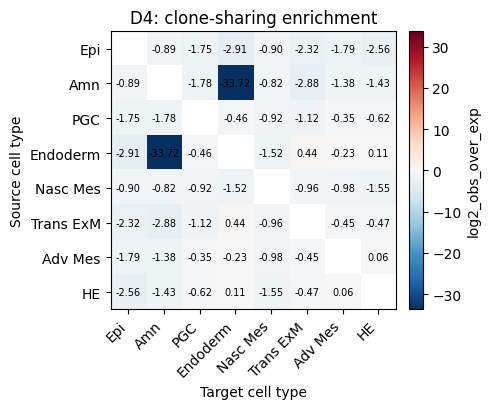

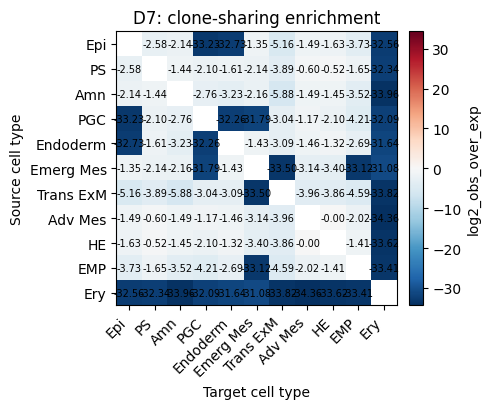

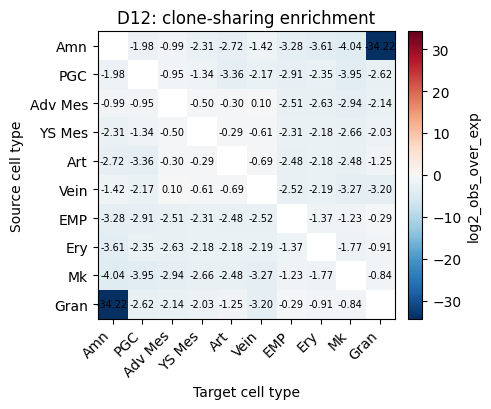

In [22]:
for day in ["D4", "D7", "D12"]:
    plot_source_target_heatmap(
        source_target_df,
        day=day,
        value_key="log2_obs_over_exp",
        source_order=source_order,
        target_order=target_order,
        figsize=(5.0, 4.2),
        cmap="RdBu_r",
        center_zero=True,
        annotate=True,
        fmt=".2f",
        title=f"{day}: clone-sharing enrichment",
        save=fig_dir / f"{day.lower()}_source_target_log2_obs_over_exp_heatmap.pdf",
    )

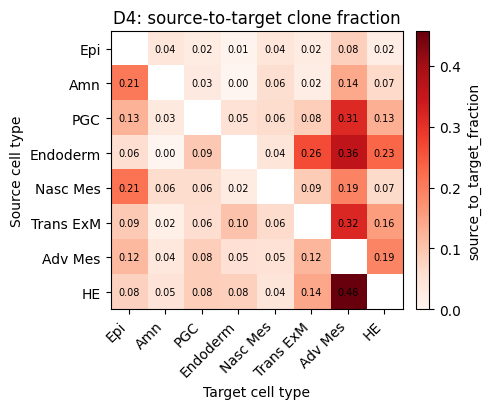

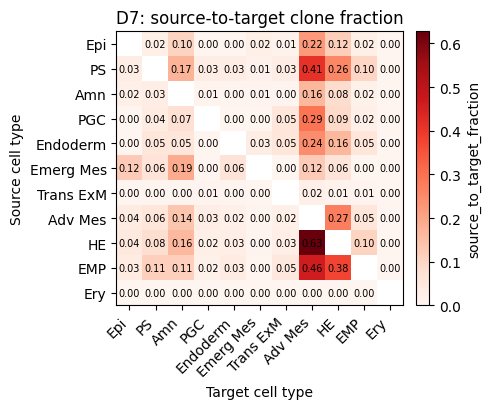

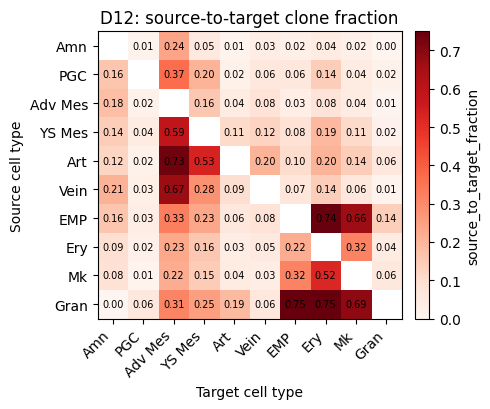

In [23]:
for day in ["D4", "D7", "D12"]:
    plot_source_target_heatmap(
        source_target_df,
        day=day,
        value_key="source_to_target_fraction",
        source_order=source_order,
        target_order=target_order,
        figsize=(5.0, 4.2),
        cmap="Reds",
        center_zero=False,
        vmin=0,
        vmax=None,
        annotate=True,
        fmt=".2f",
        title=f"{day}: source-to-target clone fraction",
        save=fig_dir / f"{day.lower()}_source_to_target_fraction_heatmap.pdf",
    )

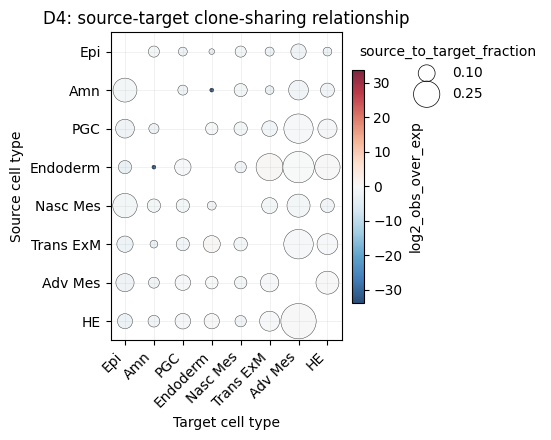

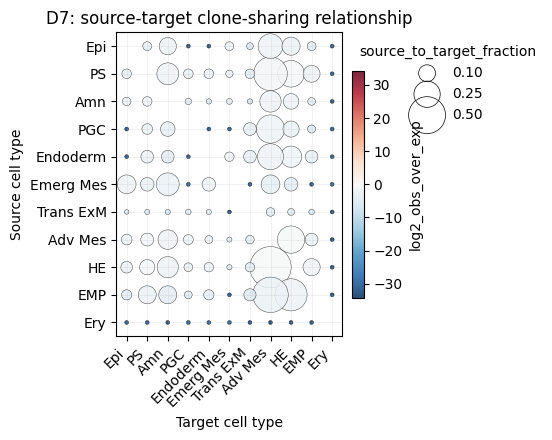

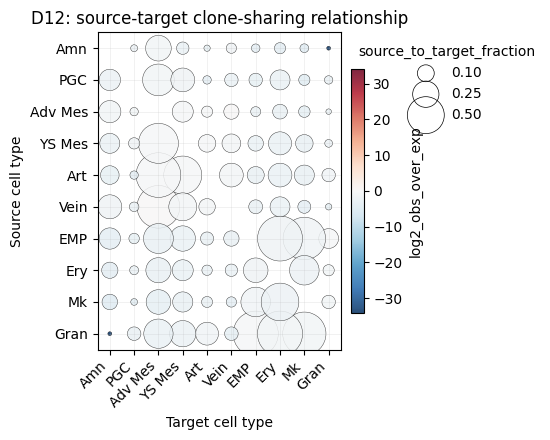

In [24]:
for day in ["D4", "D7", "D12"]:
    plot_source_target_bubble(
        source_target_df,
        day=day,
        source_order=source_order,
        target_order=target_order,
        size_key="source_to_target_fraction",
        color_key="log2_obs_over_exp",
        size_scale=1400,
        min_size=8,
        figsize=(5.5, 4.5),
        cmap="RdBu_r",
        center_zero=True,
        title=f"{day}: source-target clone-sharing relationship",
        save=fig_dir / f"{day.lower()}_source_target_bubble.pdf",
    )

## 7. Network plot functions

Two versions are included:

- `plot_source_target_network`: curved edges, no arrowheads, reciprocal links separated.
- `plot_source_target_network_pretty`: straight edges, no arrowheads by default, labels moved farther away from nodes.

In [25]:
def plot_source_target_network(
    df,
    day,
    celltype_palette=None,
    source_order=None,
    target_order=None,
    filter_query=None,
    min_shared_clones=1,
    min_source_to_target_fraction=None,
    max_empirical_p=None,
    max_fdr=None,
    min_log2_obs_over_exp=None,
    edge_width_key="source_to_target_fraction",
    node_size_key="n_clones",
    edge_width_scale=12,
    min_edge_width=0.4,
    max_edge_width=7.0,
    node_size_scale=18,
    min_node_size=450,
    max_node_size=2300,
    layout="circular",
    figsize=(6.8, 6.2),
    title=None,
    save=None,
    show_edge_labels=False,
    edge_label_key="n_shared_clones",
    default_node_color="#BDBDBD",
    edge_alpha=0.65,
    arrows=False,
    label_offset=1.16,
    x_pad=0.45,
    y_pad=0.45,
    show_node_size_legend=False,
    connection_rad=0.16,
    scale_node_size=True,
    scale_edge_width=True,
):
    """
    Plot CellChat-style source-target clone-sharing network for one day.

    Edges are drawn as curved lines without arrowheads.
    Reciprocal source-target pairs are separated by opposite curvature.
    """

    df_day = df[df["day"].astype(str) == str(day)].copy()

    if df_day.shape[0] == 0:
        raise ValueError(f"No data found for day: {day}")

    if source_order is not None:
        df_day = df_day[df_day["source"].isin(source_order)].copy()

    if target_order is not None:
        df_day = df_day[df_day["target"].isin(target_order)].copy()

    df_day = df_day[df_day["n_shared_clones"] >= min_shared_clones].copy()

    if min_source_to_target_fraction is not None:
        df_day = df_day[
            df_day["source_to_target_fraction"] >= min_source_to_target_fraction
        ].copy()

    if max_empirical_p is not None:
        df_day = df_day[df_day["empirical_p"] <= max_empirical_p].copy()

    if max_fdr is not None:
        df_day = df_day[df_day["fdr"] <= max_fdr].copy()

    if min_log2_obs_over_exp is not None:
        df_day = df_day[
            df_day["log2_obs_over_exp"] >= min_log2_obs_over_exp
        ].copy()

    if filter_query is not None:
        df_day = df_day.query(filter_query).copy()

    if df_day.shape[0] == 0:
        print(f"No edges left after filtering for {day}.")
        return None, None, df_day

    nodes = sorted(set(df_day["source"]).union(set(df_day["target"])))

    if source_order is not None or target_order is not None:
        preferred_order = []
        if source_order is not None:
            preferred_order.extend(source_order)
        if target_order is not None:
            preferred_order.extend(target_order)

        preferred_order = [x for x in preferred_order if x in nodes]
        remaining = [x for x in nodes if x not in preferred_order]
        nodes = preferred_order + sorted(remaining)

    G = nx.DiGraph()
    G.add_nodes_from(nodes)

    for _, row in df_day.iterrows():
        G.add_edge(
            row["source"],
            row["target"],
            weight=row[edge_width_key],
            n_shared_clones=row["n_shared_clones"],
            source_to_target_fraction=row["source_to_target_fraction"],
            target_from_source_fraction=row["target_from_source_fraction"],
            log2_obs_over_exp=row["log2_obs_over_exp"],
            empirical_p=row["empirical_p"],
            fdr=row["fdr"],
        )

    node_stats = {}

    for node in nodes:
        source_part = df_day[df_day["source"] == node]
        target_part = df_day[df_day["target"] == node]

        n_source_clones = (
            source_part["n_source_clones"].max()
            if source_part.shape[0] > 0 else 0
        )
        n_target_clones = (
            target_part["n_target_clones"].max()
            if target_part.shape[0] > 0 else 0
        )

        n_source_cells = (
            source_part["n_source_cells"].max()
            if source_part.shape[0] > 0 else 0
        )
        n_target_cells = (
            target_part["n_target_cells"].max()
            if target_part.shape[0] > 0 else 0
        )

        node_stats[node] = {
            "n_clones": max(n_source_clones, n_target_clones),
            "n_cells": max(n_source_cells, n_target_cells),
        }

    node_values = np.array([node_stats[n][node_size_key] for n in nodes], dtype=float)

    if scale_node_size:
        positive_node_values = node_values[node_values > 0]

        if len(positive_node_values) > 0 and np.nanmax(node_values) > np.nanmin(node_values):
            sqrt_values = np.sqrt(node_values)
            sqrt_min = np.nanmin(sqrt_values)
            sqrt_max = np.nanmax(sqrt_values)

            node_sizes = (
                min_node_size
                + (sqrt_values - sqrt_min) / (sqrt_max - sqrt_min)
                * (max_node_size - min_node_size)
            )
        else:
            node_sizes = np.repeat((min_node_size + max_node_size) / 2, len(nodes))
    else:
        node_sizes = node_values * node_size_scale + min_node_size

    if celltype_palette is None:
        celltype_palette = {}

    node_colors = [
        celltype_palette.get(node, default_node_color)
        for node in nodes
    ]

    if layout == "circular":
        G_ordered = nx.DiGraph()
        G_ordered.add_nodes_from(nodes)
        G_ordered.add_edges_from(G.edges(data=True))
        pos = nx.circular_layout(G_ordered)

    elif layout == "spring":
        pos = nx.spring_layout(
            G,
            seed=0,
            k=1.0 / np.sqrt(max(len(nodes), 1)),
            weight="weight",
        )

    elif layout == "shell":
        pos = nx.shell_layout(G)

    else:
        raise ValueError("layout must be one of: 'circular', 'spring', 'shell'")

    edge_list = list(G.edges())

    edge_values = np.array(
        [G.edges[e]["weight"] for e in edge_list],
        dtype=float,
    )

    if edge_width_key == "log2_obs_over_exp":
        edge_values_for_width = np.clip(edge_values, a_min=0, a_max=None)
    else:
        edge_values_for_width = edge_values

    if scale_edge_width:
        if len(edge_values_for_width) > 0 and np.nanmax(edge_values_for_width) > np.nanmin(edge_values_for_width):
            edge_widths = (
                min_edge_width
                + (edge_values_for_width - np.nanmin(edge_values_for_width))
                / (np.nanmax(edge_values_for_width) - np.nanmin(edge_values_for_width))
                * (max_edge_width - min_edge_width)
            )
        else:
            edge_widths = np.repeat((min_edge_width + max_edge_width) / 2, len(edge_values_for_width))
    else:
        edge_widths = edge_values_for_width * edge_width_scale + min_edge_width

    edge_colors = [
        celltype_palette.get(u, default_node_color)
        for u, v in edge_list
    ]

    fig, ax = plt.subplots(figsize=figsize)

    for edge_idx, (u, v) in enumerate(edge_list):
        x1, y1 = pos[u]
        x2, y2 = pos[v]

        if G.has_edge(v, u):
            rad = connection_rad if nodes.index(u) < nodes.index(v) else -connection_rad
        else:
            rad = connection_rad

        edge = FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="-",
            connectionstyle=f"arc3,rad={rad}",
            linewidth=edge_widths[edge_idx],
            color=edge_colors[edge_idx],
            alpha=edge_alpha,
            shrinkA=18,
            shrinkB=18,
            zorder=1,
        )

        ax.add_patch(edge)

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=nodes,
        node_color=node_colors,
        node_size=node_sizes,
        edgecolors="black",
        linewidths=0.7,
        ax=ax,
    )

    label_pos = {}

    node_size_map = {
        n: node_sizes[i]
        for i, n in enumerate(nodes)
    }

    for n, (x, y) in pos.items():
        r = np.sqrt(x**2 + y**2)

        if r == 0:
            dx, dy = 0, 1
        else:
            dx, dy = x / r, y / r

        size_offset = np.sqrt(node_size_map[n]) / 180

        label_pos[n] = (
            x * label_offset + dx * size_offset,
            y * label_offset + dy * size_offset,
        )

    nx.draw_networkx_labels(
        G,
        label_pos,
        labels={n: n for n in nodes},
        font_size=9,
        font_color="black",
        ax=ax,
    )

    if show_edge_labels:
        edge_labels = {
            (u, v): f"{G.edges[(u, v)][edge_label_key]:.2g}"
            for u, v in G.edges()
        }

        nx.draw_networkx_edge_labels(
            G,
            pos,
            edge_labels=edge_labels,
            font_size=7,
            label_pos=0.55,
            ax=ax,
        )

    all_x = np.array(
        [p[0] for p in pos.values()] + [p[0] for p in label_pos.values()]
    )
    all_y = np.array(
        [p[1] for p in pos.values()] + [p[1] for p in label_pos.values()]
    )

    ax.set_xlim(all_x.min() - x_pad, all_x.max() + x_pad)
    ax.set_ylim(all_y.min() - y_pad, all_y.max() + y_pad)

    if title is None:
        title = f"{day}: source-target clone-sharing network"

    ax.set_title(title, fontsize=12, pad=12)
    ax.axis("off")
    ax.set_aspect("equal")

    if show_node_size_legend:
        positive_values = node_values[node_values > 0]

        if len(positive_values) > 0:
            example_values = np.nanpercentile(positive_values, [25, 50, 75])
            example_values = np.unique(np.round(example_values).astype(int))

            handles = []
            labels = []

            for v in example_values:
                if v <= 0:
                    continue

                if scale_node_size and np.nanmax(node_values) > np.nanmin(node_values):
                    sqrt_values = np.sqrt(node_values)
                    sqrt_min = np.nanmin(sqrt_values)
                    sqrt_max = np.nanmax(sqrt_values)

                    size_v = (
                        min_node_size
                        + (np.sqrt(v) - sqrt_min) / (sqrt_max - sqrt_min)
                        * (max_node_size - min_node_size)
                    )
                else:
                    size_v = v * node_size_scale + min_node_size

                handles.append(
                    ax.scatter(
                        [],
                        [],
                        s=size_v,
                        facecolors="white",
                        edgecolors="black",
                        linewidths=0.7,
                    )
                )
                labels.append(str(v))

            if len(handles) > 0:
                ax.legend(
                    handles,
                    labels,
                    title=node_size_key,
                    frameon=False,
                    loc="center left",
                    bbox_to_anchor=(1.02, 0.5),
                    labelspacing=1.4,
                    borderaxespad=0,
                )

    fig.tight_layout()

    if save is not None:
        fig.savefig(save, bbox_inches="tight", facecolor="white")

    plt.show()

    return fig, ax, df_day

In [26]:
def plot_source_target_network_pretty(
    df,
    day,
    celltype_palette,
    source_order=None,
    target_order=None,
    min_shared_clones=1,
    edge_width_key="n_shared_clones",
    node_size_key="n_clones",
    edge_width_scale=1.0,
    min_edge_width=0.4,
    max_edge_width=8.0,
    min_node_size=450,
    max_node_size=2600,
    layout="circular",
    figsize=(6.5, 6.2),
    title=None,
    save=None,
    arrows=False,
    show_node_size_legend=True,
    show_celltype_legend=False,
    label_offset=1.28,
    edge_alpha=0.65,
    connection_rad=0.16,
    default_node_color="#BDBDBD",
):
    """
    Pretty CellChat-style network plot for source-target clone-sharing relationships.

    This version uses straight edges, no arrowheads by default,
    and moves labels farther away from nodes based on node size.
    """

    df_day = df[df["day"].astype(str) == str(day)].copy()

    if source_order is not None:
        df_day = df_day[df_day["source"].isin(source_order)].copy()

    if target_order is not None:
        df_day = df_day[df_day["target"].isin(target_order)].copy()

    df_day = df_day[df_day["n_shared_clones"] >= min_shared_clones].copy()

    if df_day.shape[0] == 0:
        print(f"No edges left for {day}.")
        return None, None, df_day

    nodes = sorted(set(df_day["source"]).union(set(df_day["target"])))

    preferred_order = []
    if source_order is not None:
        preferred_order.extend(source_order)
    if target_order is not None:
        preferred_order.extend(target_order)

    preferred_order = [x for x in preferred_order if x in nodes]
    remaining = [x for x in nodes if x not in preferred_order]
    nodes = preferred_order + sorted(remaining)

    G = nx.DiGraph()
    G.add_nodes_from(nodes)

    for _, row in df_day.iterrows():
        G.add_edge(
            row["source"],
            row["target"],
            weight=row[edge_width_key],
            n_shared_clones=row["n_shared_clones"],
            source_to_target_fraction=row["source_to_target_fraction"],
            target_from_source_fraction=row["target_from_source_fraction"],
            log2_obs_over_exp=row["log2_obs_over_exp"],
            empirical_p=row["empirical_p"],
            fdr=row["fdr"],
        )

    node_stats = {}

    for node in nodes:
        source_part = df_day[df_day["source"] == node]
        target_part = df_day[df_day["target"] == node]

        n_source_clones = (
            source_part["n_source_clones"].max()
            if source_part.shape[0] > 0 else 0
        )
        n_target_clones = (
            target_part["n_target_clones"].max()
            if target_part.shape[0] > 0 else 0
        )

        n_source_cells = (
            source_part["n_source_cells"].max()
            if source_part.shape[0] > 0 else 0
        )
        n_target_cells = (
            target_part["n_target_cells"].max()
            if target_part.shape[0] > 0 else 0
        )

        node_stats[node] = {
            "n_clones": max(n_source_clones, n_target_clones),
            "n_cells": max(n_source_cells, n_target_cells),
        }

    node_values = np.array([node_stats[n][node_size_key] for n in nodes], dtype=float)

    if np.nanmax(node_values) > np.nanmin(node_values):
        scaled_node = (
            (np.sqrt(node_values) - np.sqrt(np.nanmin(node_values)))
            / (np.sqrt(np.nanmax(node_values)) - np.sqrt(np.nanmin(node_values)))
        )
        node_sizes = min_node_size + scaled_node * (max_node_size - min_node_size)
    else:
        node_sizes = np.repeat((min_node_size + max_node_size) / 2, len(nodes))

    node_colors = [
        celltype_palette.get(n, default_node_color)
        for n in nodes
    ]

    if layout == "circular":
        G_ordered = nx.DiGraph()
        G_ordered.add_nodes_from(nodes)
        G_ordered.add_edges_from(G.edges(data=True))
        pos = nx.circular_layout(G_ordered)

    elif layout == "spring":
        pos = nx.spring_layout(
            G,
            seed=0,
            k=1.0 / np.sqrt(max(len(nodes), 1)),
            weight="weight",
        )

    elif layout == "shell":
        pos = nx.shell_layout(G)

    else:
        raise ValueError("layout must be one of: circular, spring, shell")

    edge_list = list(G.edges())

    raw_edge_values = np.array(
        [G.edges[e]["weight"] for e in edge_list],
        dtype=float,
    )

    if edge_width_key == "log2_obs_over_exp":
        raw_edge_values = np.clip(raw_edge_values, a_min=0, a_max=None)

    if np.nanmax(raw_edge_values) > np.nanmin(raw_edge_values):
        edge_widths = (
            min_edge_width
            + (raw_edge_values - np.nanmin(raw_edge_values))
            / (np.nanmax(raw_edge_values) - np.nanmin(raw_edge_values))
            * (max_edge_width - min_edge_width)
        )
    else:
        edge_widths = np.repeat(
            (min_edge_width + max_edge_width) / 2,
            len(raw_edge_values),
        )

    edge_colors = [
        celltype_palette.get(u, default_node_color)
        for u, v in edge_list
    ]

    fig, ax = plt.subplots(figsize=figsize)

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=edge_list,
        width=edge_widths,
        edge_color=edge_colors,
        alpha=edge_alpha,
        arrows=arrows,
        arrowstyle="-|>",
        arrowsize=10,
        connectionstyle=f"arc3,rad={connection_rad}",
        ax=ax,
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=nodes,
        node_color=node_colors,
        node_size=node_sizes,
        edgecolors="black",
        linewidths=0.8,
        ax=ax,
    )

    label_pos = {}

    node_size_map = {
        n: node_sizes[i]
        for i, n in enumerate(nodes)
    }

    for n, (x, y) in pos.items():
        r = np.sqrt(x**2 + y**2)

        if r == 0:
            dx, dy = 0, 1
        else:
            dx, dy = x / r, y / r

        size_offset = np.sqrt(node_size_map[n]) / 180

        label_pos[n] = (
            x * label_offset + dx * size_offset,
            y * label_offset + dy * size_offset,
        )

    nx.draw_networkx_labels(
        G,
        label_pos,
        labels={n: n for n in nodes},
        font_size=9,
        font_color="black",
        font_weight="normal",
        ax=ax,
    )

    all_x = np.array(
        [p[0] for p in pos.values()] + [p[0] for p in label_pos.values()]
    )
    all_y = np.array(
        [p[1] for p in pos.values()] + [p[1] for p in label_pos.values()]
    )

    x_pad = 0.60
    y_pad = 0.55

    ax.set_xlim(all_x.min() - x_pad, all_x.max() + x_pad)
    ax.set_ylim(all_y.min() - y_pad, all_y.max() + y_pad)

    if title is None:
        title = f"{day}: clone-sharing network"

    ax.set_title(title, fontsize=12, pad=12)
    ax.axis("off")
    ax.set_aspect("equal")

    if show_node_size_legend:
        positive_values = node_values[node_values > 0]

        if len(positive_values) > 0:
            legend_values = np.nanpercentile(positive_values, [25, 50, 75])
            legend_values = np.unique(np.round(legend_values).astype(int))

            handles = []
            labels = []

            for v in legend_values:
                if v <= 0:
                    continue

                if np.nanmax(node_values) > np.nanmin(node_values):
                    scaled_v = (
                        (np.sqrt(v) - np.sqrt(np.nanmin(node_values)))
                        / (np.sqrt(np.nanmax(node_values)) - np.sqrt(np.nanmin(node_values)))
                    )
                    size_v = min_node_size + scaled_v * (max_node_size - min_node_size)
                else:
                    size_v = (min_node_size + max_node_size) / 2

                handles.append(
                    plt.scatter(
                        [],
                        [],
                        s=size_v,
                        facecolors="white",
                        edgecolors="black",
                        linewidths=0.8,
                    )
                )
                labels.append(str(v))

            if len(handles) > 0:
                leg1 = ax.legend(
                    handles,
                    labels,
                    title=node_size_key,
                    frameon=False,
                    scatterpoints=1,
                    loc="center left",
                    bbox_to_anchor=(1.02, 0.5),
                    borderaxespad=0,
                    labelspacing=1.4,
                )
                ax.add_artist(leg1)

    if show_celltype_legend:
        legend_nodes = [n for n in nodes if n in celltype_palette]

        color_handles = [
            Line2D(
                [0],
                [0],
                marker="o",
                color="none",
                markerfacecolor=celltype_palette[n],
                markeredgecolor="black",
                markersize=8,
                label=n,
            )
            for n in legend_nodes
        ]

        ax.legend(
            handles=color_handles,
            title="Cell type",
            frameon=False,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
        )

    fig.tight_layout()

    if save is not None:
        fig.savefig(save, bbox_inches="tight", facecolor="white")

    plt.show()

    return fig, ax, df_day

## 10. Alluvial plot

In [ ]:
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch, Rectangle

def plot_source_target_alluvial(
    df,
    day,
    celltype_palette=None,
    source_order=None,
    target_order=None,
    value_key="n_shared_clones",
    min_shared_clones=1,
    filter_query=None,
    top_n=None,
    figsize=(5.8, 4.8),
    source_label="Source cell type",
    target_label="Target cell type",
    title=None,
    save=None,
    alpha=0.55,
    bar_width=0.035,
    gap=0.035,
    ribbon_curve=0.42,
    label_fontsize=9,
    title_fontsize=12,
    default_color="#BDBDBD",
):
    """
    Two-column alluvial / Sankey-like plot for within-day source-target clone-sharing.

    Recommended:
        value_key = "n_shared_clones"

    Notes:
        This visualizes clone-sharing relationships within the same day/experiment.
        It does not imply cross-day differentiation trajectory.
    """

    df_day = df[df["day"].astype(str) == str(day)].copy()

    if df_day.shape[0] == 0:
        raise ValueError(f"No data found for day: {day}")

    if source_order is not None:
        df_day = df_day[df_day["source"].isin(source_order)].copy()

    if target_order is not None:
        df_day = df_day[df_day["target"].isin(target_order)].copy()

    df_day = df_day[df_day["n_shared_clones"] >= min_shared_clones].copy()

    if filter_query is not None:
        df_day = df_day.query(filter_query).copy()

    if df_day.shape[0] == 0:
        print(f"No links left for {day}.")
        return None, None, df_day

    df_day = (
        df_day
        .groupby(["source", "target"], as_index=False)[value_key]
        .sum()
    )

    df_day = df_day[df_day[value_key] > 0].copy()

    if top_n is not None:
        df_day = (
            df_day
            .sort_values(value_key, ascending=False)
            .head(top_n)
            .copy()
        )

    if df_day.shape[0] == 0:
        print(f"No positive {value_key} links left for {day}.")
        return None, None, df_day

    if source_order is None:
        sources = (
            df_day.groupby("source")[value_key]
            .sum()
            .sort_values(ascending=False)
            .index
            .tolist()
        )
    else:
        sources = [x for x in source_order if x in set(df_day["source"])]

    if target_order is None:
        targets = (
            df_day.groupby("target")[value_key]
            .sum()
            .sort_values(ascending=False)
            .index
            .tolist()
        )
    else:
        targets = [x for x in target_order if x in set(df_day["target"])]

    df_day["source"] = pd.Categorical(
        df_day["source"],
        categories=sources,
        ordered=True,
    )
    df_day["target"] = pd.Categorical(
        df_day["target"],
        categories=targets,
        ordered=True,
    )

    df_day = df_day.sort_values(["source", "target"]).copy()

    total_value = df_day[value_key].sum()

    if total_value <= 0:
        print(f"No positive {value_key} for {day}.")
        return None, None, df_day

    source_totals = (
        df_day.groupby("source", observed=True)[value_key]
        .sum()
        .reindex(sources)
        .fillna(0)
    )

    target_totals = (
        df_day.groupby("target", observed=True)[value_key]
        .sum()
        .reindex(targets)
        .fillna(0)
    )

    def make_intervals(categories, totals):
        n = len(categories)
        usable_height = 1.0 - gap * max(n - 1, 0)

        heights = totals / total_value * usable_height

        intervals = {}
        y_top = 1.0

        for cat, h in zip(categories, heights):
            y1 = y_top
            y0 = y_top - h
            intervals[cat] = [y0, y1]
            y_top = y0 - gap

        return intervals

    source_intervals = make_intervals(sources, source_totals)
    target_intervals = make_intervals(targets, target_totals)

    # Allocate link segments within each source and target bar
    source_cursor = {s: source_intervals[s][1] for s in sources}
    target_cursor = {t: target_intervals[t][1] for t in targets}

    source_usable_height = 1.0 - gap * max(len(sources) - 1, 0)
    scale_height = source_usable_height / total_value

    links = []

    for _, row in df_day.iterrows():
        s = row["source"]
        t = row["target"]
        v = row[value_key]

        h = v * scale_height

        sy1 = source_cursor[s]
        sy0 = sy1 - h
        source_cursor[s] = sy0

        ty1 = target_cursor[t]
        ty0 = ty1 - h
        target_cursor[t] = ty0

        links.append({
            "source": s,
            "target": t,
            "value": v,
            "sy0": sy0,
            "sy1": sy1,
            "ty0": ty0,
            "ty1": ty1,
        })

    if celltype_palette is None:
        celltype_palette = {}

    fig, ax = plt.subplots(figsize=figsize)

    x_left = 0.0
    x_right = 1.0
    x0 = x_left + bar_width
    x1 = x_right - bar_width

    # Draw ribbons
    for link in links:
        s = str(link["source"])
        color = celltype_palette.get(s, default_color)

        sy0, sy1 = link["sy0"], link["sy1"]
        ty0, ty1 = link["ty0"], link["ty1"]

        verts = [
            (x0, sy1),
            (x0 + ribbon_curve, sy1),
            (x1 - ribbon_curve, ty1),
            (x1, ty1),
            (x1, ty0),
            (x1 - ribbon_curve, ty0),
            (x0 + ribbon_curve, sy0),
            (x0, sy0),
            (x0, sy1),
        ]

        codes = [
            MplPath.MOVETO,
            MplPath.CURVE4,
            MplPath.CURVE4,
            MplPath.CURVE4,
            MplPath.LINETO,
            MplPath.CURVE4,
            MplPath.CURVE4,
            MplPath.CURVE4,
            MplPath.CLOSEPOLY,
            ]

        patch = PathPatch(
            MplPath(verts, codes),
            facecolor=color,
            edgecolor="none",
            alpha=alpha,
            zorder=1,
            )

        ax.add_patch(patch)

    # Draw source bars
    for s in sources:
        y0, y1 = source_intervals[s]
        color = celltype_palette.get(str(s), default_color)

        ax.add_patch(
            Rectangle(
                (x_left, y0),
                bar_width,
                y1 - y0,
                facecolor=color,
                edgecolor="black",
                linewidth=0.6,
                zorder=3,
            )
        )

        ax.text(
            x_left - 0.025,
            (y0 + y1) / 2,
            str(s),
            ha="right",
            va="center",
            fontsize=label_fontsize,
        )

    # Draw target bars
    for t in targets:
        y0, y1 = target_intervals[t]
        color = celltype_palette.get(str(t), default_color)

        ax.add_patch(
            Rectangle(
                (x_right - bar_width, y0),
                bar_width,
                y1 - y0,
                facecolor=color,
                edgecolor="black",
                linewidth=0.6,
                zorder=3,
            )
        )

        ax.text(
            x_right + 0.025,
            (y0 + y1) / 2,
            str(t),
            ha="left",
            va="center",
            fontsize=label_fontsize,
        )

    ax.text(
        x_left + bar_width / 2,
        1.05,
        source_label,
        ha="center",
        va="bottom",
        fontsize=label_fontsize,
    )

    ax.text(
        x_right - bar_width / 2,
        1.05,
        target_label,
        ha="center",
        va="bottom",
        fontsize=label_fontsize,
    )

    if title is None:
        title = f"{day}: source-target clone-sharing alluvial"

    ax.set_title(title, fontsize=title_fontsize, pad=14)

    ax.set_xlim(-0.42, 1.42)
    ax.set_ylim(-0.03, 1.10)
    ax.axis("off")

    fig.tight_layout()

    if save is not None:
        fig.savefig(save, bbox_inches="tight", facecolor="white")

    plt.show()

    return fig, ax, df_day

In [ ]:
source_celltypes = [
    # epithelial / early populations
    "Epi",
    "PS",
    "Amn",
    "PGC",

    # endoderm / mesoderm / ExM
    "Endoderm",
    "Nasc Mes",
    "Emerg Mes",
    "Trans ExM",
    "Adv Mes",
    "YS Mes",

    # endothelial
    "HE",
    "Art",
    "Vein",

    # blood
    "EMP",
    "Ery",
    "Mk",
    "Gran",
]

target_celltypes = [
    "Epi",
    "PS",
    "Amn",
    "PGC",
    "Endoderm",
    "Nasc Mes",
    "Emerg Mes",
    "Trans ExM",
    "Adv Mes",
    "YS Mes",
    "HE",
    "Art",
    "Vein",
    "EMP",
    "Ery",
    "Mk",
    "Gran",
]

source_order = source_celltypes
target_order = target_celltypes
celltype_order = source_celltypes

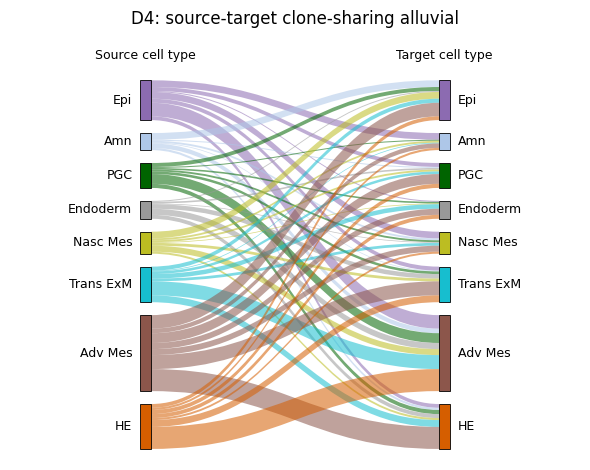

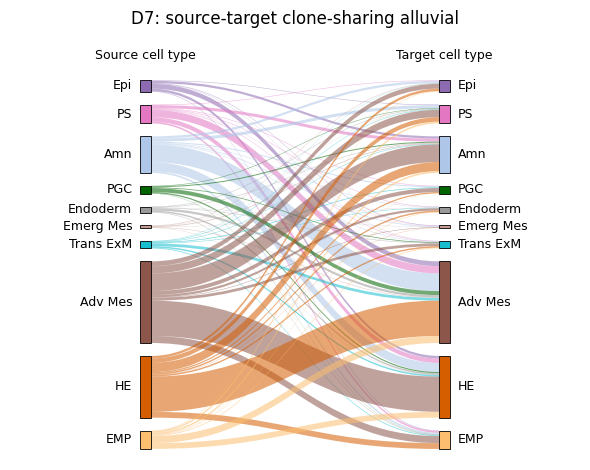

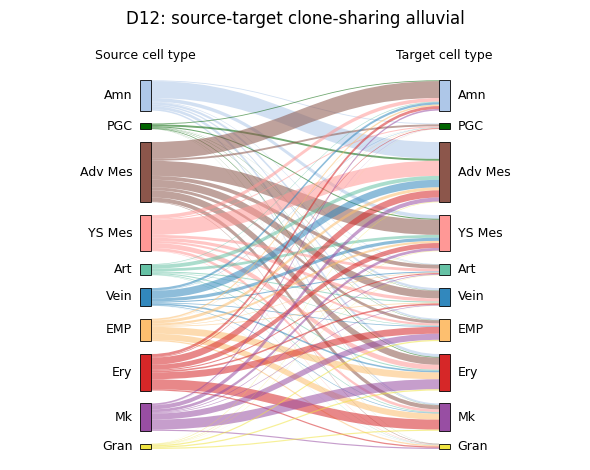

In [ ]:
for day in ["D4", "D7", "D12"]:
    plot_source_target_alluvial(
        source_target_df,
        day=day,
        celltype_palette=celltype_palette,
        source_order=source_order,
        target_order=target_order,
        value_key="n_shared_clones",
        min_shared_clones=1,
        figsize=(6.0, 4.8),
        title=f"{day}: source-target clone-sharing alluvial",
        save=fig_dir / f"{day.lower()}_source_target_alluvial.pdf",
        alpha=0.55,
        label_fontsize=9,
    )

In [ ]:
source_celltypes = [
    "Endoderm",
]

target_celltypes = [
    "Epi",
    "PS",
    "Amn",
    "PGC",
    "Endoderm",
    "Nasc Mes",
    "Emerg Mes",
    "Trans ExM",
    "Adv Mes",
    "YS Mes",
    "HE",
    "Art",
    "Vein",
    "EMP",
    "Ery",
    "Mk",
    "Gran",
]

source_order = source_celltypes
target_order = target_celltypes
celltype_order = source_celltypes

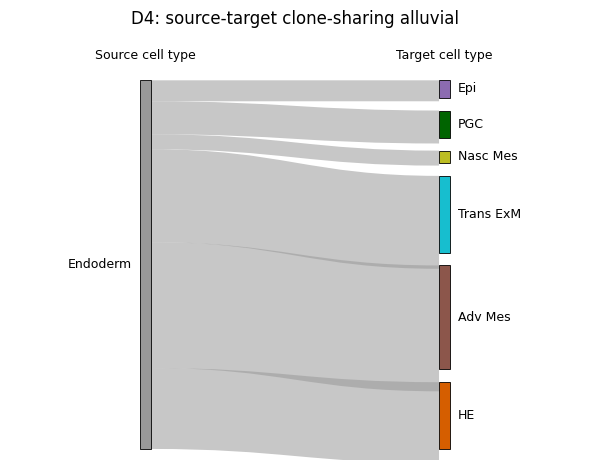

In [ ]:
for day in ["D4"]:
    plot_source_target_alluvial(
        source_target_df,
        day=day,
        celltype_palette=celltype_palette,
        source_order=source_order,
        target_order=target_order,
        value_key="n_shared_clones",
        min_shared_clones=1,
        figsize=(6.0, 4.8),
        title=f"{day}: source-target clone-sharing alluvial",
        save=fig_dir / f"{day.lower()}_endo_to_all_alluvial.pdf",
        alpha=0.55,
        label_fontsize=9,
    )

In [ ]:
source_celltypes = [
    "Adv Mes",
]

target_celltypes = [
    "Epi",
    "PS",
    "Amn",
    "PGC",
    "Endoderm",
    "Nasc Mes",
    "Emerg Mes",
    "Trans ExM",
    "Adv Mes",
    "YS Mes",
    "HE",
    "Art",
    "Vein",
    "EMP",
    "Ery",
    "Mk",
    "Gran",
]

source_order = source_celltypes
target_order = target_celltypes
celltype_order = source_celltypes

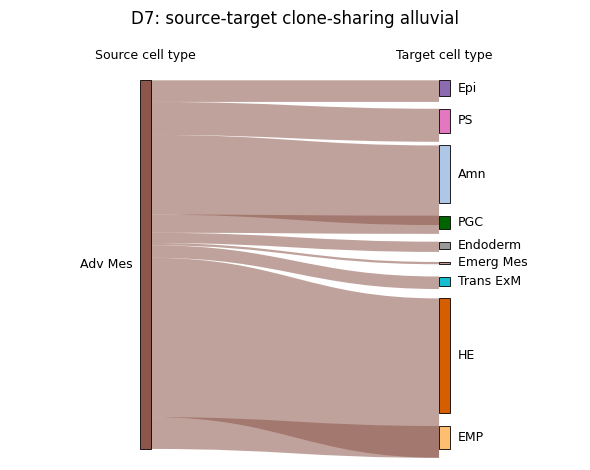

In [ ]:
for day in ["D7"]:
    plot_source_target_alluvial(
        source_target_df,
        day=day,
        celltype_palette=celltype_palette,
        source_order=source_order,
        target_order=target_order,
        value_key="n_shared_clones",
        min_shared_clones=1,
        figsize=(6.0, 4.8),
        title=f"{day}: source-target clone-sharing alluvial",
        save=fig_dir / f"{day.lower()}_advmes_to_all_alluvial.pdf",
        alpha=0.55,
        label_fontsize=9,
    )

In [ ]:
source_celltypes = [
    "EMP",
]

target_celltypes = [
    "Epi",
    "PS",
    "Amn",
    "PGC",
    "Endoderm",
    "Nasc Mes",
    "Emerg Mes",
    "Trans ExM",
    "Adv Mes",
    "YS Mes",
    "HE",
    "Art",
    "Vein",
    "EMP",
    "Ery",
    "Mk",
    "Gran",
]

source_order = source_celltypes
target_order = target_celltypes
celltype_order = source_celltypes

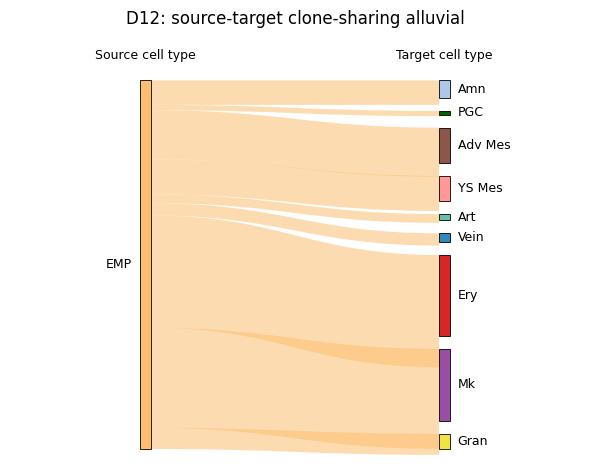

In [ ]:
for day in ["D12"]:
    plot_source_target_alluvial(
        source_target_df,
        day=day,
        celltype_palette=celltype_palette,
        source_order=source_order,
        target_order=target_order,
        value_key="n_shared_clones",
        min_shared_clones=1,
        figsize=(6.0, 4.8),
        title=f"{day}: source-target clone-sharing alluvial",
        save=fig_dir / f"{day.lower()}_emp_to_all_alluvial.pdf",
        alpha=0.55,
        label_fontsize=9,
    )

In [ ]:
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch, Rectangle

def plot_source_target_alluvial_highlight(
    df,
    day,
    celltype_palette=None,
    source_order=None,
    target_order=None,
    value_key="n_shared_clones",
    min_shared_clones=1,
    filter_query=None,
    top_n=None,
    highlight_sources=None,
    highlight_targets=None,
    figsize=(5.8, 4.8),
    source_label="Source cell type",
    target_label="Target cell type",
    title=None,
    save=None,
    alpha=0.65,
    background_alpha=0.18,
    bar_width=0.035,
    gap=0.035,
    ribbon_curve=0.42,
    label_fontsize=9,
    title_fontsize=12,
    default_color="#BDBDBD",
    background_color="#D0D0D0",
    dim_unhighlighted_source_bars=True,
    keep_target_bar_colors=True,
):
    """
    Two-column alluvial plot with highlighted source and/or target populations.

    Important:
        This function does NOT subset to highlighted sources.
        It keeps the full within-day source-target network layout,
        then visually highlights selected source-side populations.

    Recommended:
        value_key = "n_shared_clones"
        highlight_sources = ["Endoderm"] or ["Adv Mes"]
    """

    df_day = df[df["day"].astype(str) == str(day)].copy()

    if df_day.shape[0] == 0:
        raise ValueError(f"No data found for day: {day}")

    if source_order is not None:
        df_day = df_day[df_day["source"].isin(source_order)].copy()

    if target_order is not None:
        df_day = df_day[df_day["target"].isin(target_order)].copy()

    df_day = df_day[df_day["n_shared_clones"] >= min_shared_clones].copy()

    if filter_query is not None:
        df_day = df_day.query(filter_query).copy()

    if df_day.shape[0] == 0:
        print(f"No links left for {day}.")
        return None, None, df_day

    df_day = (
        df_day
        .groupby(["source", "target"], as_index=False)[value_key]
        .sum()
    )

    df_day = df_day[df_day[value_key] > 0].copy()

    if top_n is not None:
        df_day = (
            df_day
            .sort_values(value_key, ascending=False)
            .head(top_n)
            .copy()
        )

    if df_day.shape[0] == 0:
        print(f"No positive {value_key} links left for {day}.")
        return None, None, df_day

    if highlight_sources is None:
        highlight_sources = []

    if isinstance(highlight_sources, str):
        highlight_sources = [highlight_sources]

    if highlight_targets is None:
        highlight_targets = []

    if isinstance(highlight_targets, str):
        highlight_targets = [highlight_targets]

    highlight_sources = set(highlight_sources)
    highlight_targets = set(highlight_targets)

    if source_order is None:
        sources = (
            df_day.groupby("source")[value_key]
            .sum()
            .sort_values(ascending=False)
            .index
            .tolist()
        )
    else:
        sources = [x for x in source_order if x in set(df_day["source"])]

    if target_order is None:
        targets = (
            df_day.groupby("target")[value_key]
            .sum()
            .sort_values(ascending=False)
            .index
            .tolist()
        )
    else:
        targets = [x for x in target_order if x in set(df_day["target"])]

    df_day["source"] = pd.Categorical(
        df_day["source"],
        categories=sources,
        ordered=True,
    )

    df_day["target"] = pd.Categorical(
        df_day["target"],
        categories=targets,
        ordered=True,
    )

    df_day = df_day.sort_values(["source", "target"]).copy()

    total_value = df_day[value_key].sum()

    source_totals = (
        df_day.groupby("source", observed=True)[value_key]
        .sum()
        .reindex(sources)
        .fillna(0)
    )

    target_totals = (
        df_day.groupby("target", observed=True)[value_key]
        .sum()
        .reindex(targets)
        .fillna(0)
    )

    def make_intervals(categories, totals):
        n = len(categories)
        usable_height = 1.0 - gap * max(n - 1, 0)
        heights = totals / total_value * usable_height

        intervals = {}
        y_top = 1.0

        for cat, h in zip(categories, heights):
            y1 = y_top
            y0 = y_top - h
            intervals[cat] = [y0, y1]
            y_top = y0 - gap

        return intervals

    source_intervals = make_intervals(sources, source_totals)
    target_intervals = make_intervals(targets, target_totals)

    source_cursor = {s: source_intervals[s][1] for s in sources}
    target_cursor = {t: target_intervals[t][1] for t in targets}

    source_usable_height = 1.0 - gap * max(len(sources) - 1, 0)
    scale_height = source_usable_height / total_value

    links = []

    for _, row in df_day.iterrows():
        s = row["source"]
        t = row["target"]
        v = row[value_key]

        h = v * scale_height

        sy1 = source_cursor[s]
        sy0 = sy1 - h
        source_cursor[s] = sy0

        ty1 = target_cursor[t]
        ty0 = ty1 - h
        target_cursor[t] = ty0

        is_highlight = (
            str(s) in highlight_sources
            or str(t) in highlight_targets
            or len(highlight_sources) == 0 and len(highlight_targets) == 0
        )

        links.append({
            "source": str(s),
            "target": str(t),
            "value": v,
            "sy0": sy0,
            "sy1": sy1,
            "ty0": ty0,
            "ty1": ty1,
            "is_highlight": is_highlight,
        })

    if celltype_palette is None:
        celltype_palette = {}

    fig, ax = plt.subplots(figsize=figsize)

    x_left = 0.0
    x_right = 1.0
    x0 = x_left + bar_width
    x1 = x_right - bar_width

    # Draw background ribbons first
    for pass_name in ["background", "highlight"]:
        for link in links:
            if pass_name == "background" and link["is_highlight"]:
                continue
            if pass_name == "highlight" and not link["is_highlight"]:
                continue

            s = link["source"]

            if link["is_highlight"]:
                color = celltype_palette.get(s, default_color)
                link_alpha = alpha
                zorder = 2
            else:
                color = background_color
                link_alpha = background_alpha
                zorder = 1

            sy0, sy1 = link["sy0"], link["sy1"]
            ty0, ty1 = link["ty0"], link["ty1"]

            verts = [
                (x0, sy1),
                (x0 + ribbon_curve, sy1),
                (x1 - ribbon_curve, ty1),
                (x1, ty1),
                (x1, ty0),
                (x1 - ribbon_curve, ty0),
                (x0 + ribbon_curve, sy0),
                (x0, sy0),
                (x0, sy1),
            ]

            codes = [
                MplPath.MOVETO,
                MplPath.CURVE4,
                MplPath.CURVE4,
                MplPath.CURVE4,
                MplPath.LINETO,
                MplPath.CURVE4,
                MplPath.CURVE4,
                MplPath.CURVE4,
                MplPath.CLOSEPOLY,
            ]

            patch = PathPatch(
                MplPath(verts, codes),
                facecolor=color,
                edgecolor="none",
                alpha=link_alpha,
                zorder=zorder,
            )

            ax.add_patch(patch)

    # Source bars
    for s in sources:
        y0, y1 = source_intervals[s]
        s_str = str(s)

        if len(highlight_sources) == 0:
            facecolor = celltype_palette.get(s_str, default_color)
            edgecolor = "black"
            text_color = "black"
            linewidth = 0.6
        elif s_str in highlight_sources:
            facecolor = celltype_palette.get(s_str, default_color)
            edgecolor = "black"
            text_color = "black"
            linewidth = 0.8
        else:
            if dim_unhighlighted_source_bars:
                facecolor = background_color
                edgecolor = "#999999"
                text_color = "#999999"
                linewidth = 0.4
            else:
                facecolor = celltype_palette.get(s_str, default_color)
                edgecolor = "black"
                text_color = "black"
                linewidth = 0.6

        ax.add_patch(
            Rectangle(
                (x_left, y0),
                bar_width,
                y1 - y0,
                facecolor=facecolor,
                edgecolor=edgecolor,
                linewidth=linewidth,
                zorder=4,
            )
        )

        ax.text(
            x_left - 0.025,
            (y0 + y1) / 2,
            s_str,
            ha="right",
            va="center",
            fontsize=label_fontsize,
            color=text_color,
            fontweight="normal",
        )

    # Target bars
    for t in targets:
        y0, y1 = target_intervals[t]
        t_str = str(t)

        if keep_target_bar_colors:
            facecolor = celltype_palette.get(t_str, default_color)
        else:
            facecolor = background_color

        ax.add_patch(
            Rectangle(
                (x_right - bar_width, y0),
                bar_width,
                y1 - y0,
                facecolor=facecolor,
                edgecolor="black",
                linewidth=0.6,
                zorder=4,
            )
        )

        ax.text(
            x_right + 0.025,
            (y0 + y1) / 2,
            t_str,
            ha="left",
            va="center",
            fontsize=label_fontsize,
            color="black",
        )

    ax.text(
        x_left + bar_width / 2,
        1.05,
        source_label,
        ha="center",
        va="bottom",
        fontsize=label_fontsize,
    )

    ax.text(
        x_right - bar_width / 2,
        1.05,
        target_label,
        ha="center",
        va="bottom",
        fontsize=label_fontsize,
    )

    if title is None:
        if len(highlight_sources) > 0:
            title = f"{day}: highlighted source clone-sharing alluvial"
        else:
            title = f"{day}: source-target clone-sharing alluvial"

    ax.set_title(title, fontsize=title_fontsize, pad=14)

    ax.set_xlim(-0.42, 1.42)
    ax.set_ylim(-0.03, 1.10)
    ax.axis("off")

    fig.tight_layout()

    if save is not None:
        fig.savefig(save, bbox_inches="tight", facecolor="white")

    plt.show()

    return fig, ax, df_day

In [ ]:
source_celltypes = [
    "Epi",
    "PS",
    "Amn",
    "PGC",
    "Endoderm",
    "Nasc Mes",
    "Emerg Mes",
    "Trans ExM",
    "Adv Mes",
    "YS Mes",
    "HE",
    "Art",
    "Vein",
    "EMP",
    "Ery",
    "Mk",
    "Gran",
]

target_celltypes = [
    "Epi",
    "PS",
    "Amn",
    "PGC",
    "Endoderm",
    "Nasc Mes",
    "Emerg Mes",
    "Trans ExM",
    "Adv Mes",
    "YS Mes",
    "HE",
    "Art",
    "Vein",
    "EMP",
    "Ery",
    "Mk",
    "Gran",
]

source_order = source_celltypes
target_order = target_celltypes
celltype_order = source_celltypes

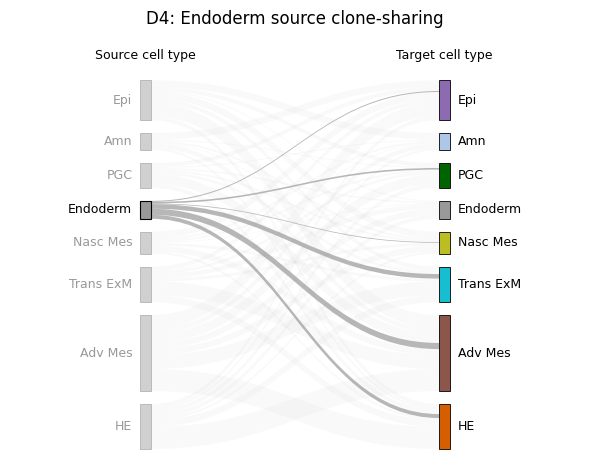

In [ ]:
for day in ["D4"]:
    plot_source_target_alluvial_highlight(
        source_target_df,
        day=day,
        celltype_palette=celltype_palette,
        source_order=source_order,
        target_order=target_order,
        value_key="n_shared_clones",
        min_shared_clones=1,
        highlight_sources=["Endoderm"],
        figsize=(6.0, 4.8),
        title=f"{day}: Endoderm source clone-sharing",
        save=fig_dir / f"{day.lower()}_source_target_alluvial_highlight_endoderm.pdf",
        alpha=0.70,
        background_alpha=0.12,
        label_fontsize=9,
    )

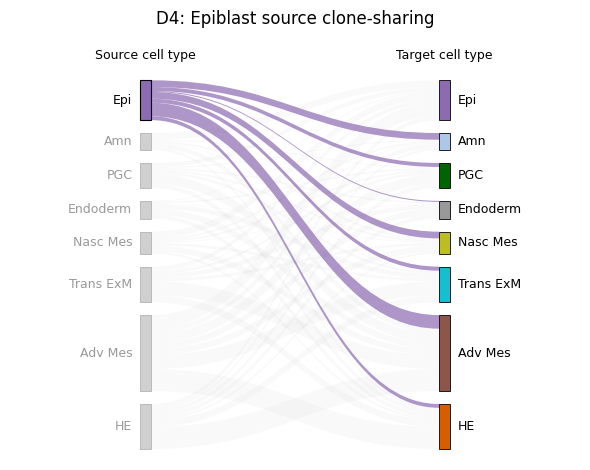

In [ ]:
for day in ["D4"]:
    plot_source_target_alluvial_highlight(
        source_target_df,
        day=day,
        celltype_palette=celltype_palette,
        source_order=source_order,
        target_order=target_order,
        value_key="n_shared_clones",
        min_shared_clones=1,
        highlight_sources=["Epi"],
        figsize=(6.0, 4.8),
        title=f"{day}: Epiblast source clone-sharing",
        save=fig_dir / f"{day.lower()}_source_target_alluvial_highlight_epi.pdf",
        alpha=0.70,
        background_alpha=0.12,
        label_fontsize=9,
    )

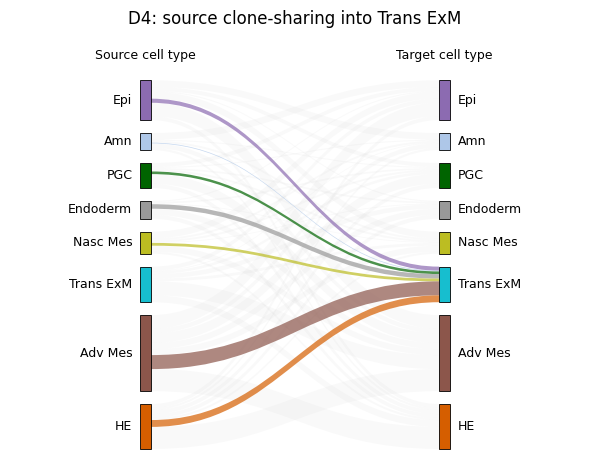

In [ ]:
for day in ["D4"]:
    plot_source_target_alluvial_highlight(
        source_target_df,
        day=day,
        celltype_palette=celltype_palette,
        source_order=source_order,
        target_order=target_order,
        value_key="n_shared_clones",
        min_shared_clones=1,
        highlight_sources=None,
        highlight_targets=["Trans ExM"],
        figsize=(6.0, 4.8),
        title=f"{day}: source clone-sharing into Trans ExM",
        save=fig_dir / f"{day.lower()}_source_target_alluvial_highlight_trans_exm.pdf",
        alpha=0.70,
        background_alpha=0.12,
        label_fontsize=9,
    )

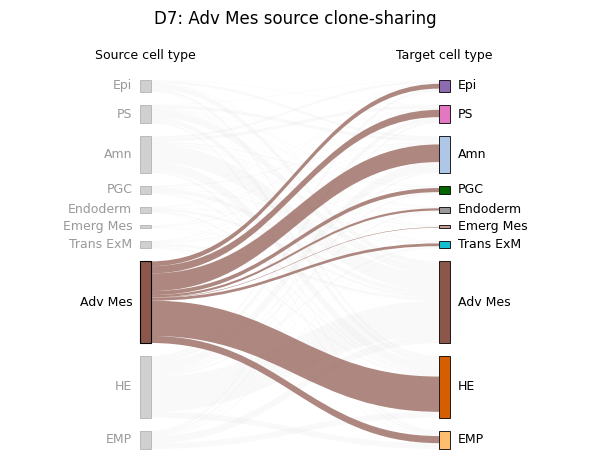

In [ ]:
for day in ["D7"]:
    plot_source_target_alluvial_highlight(
        source_target_df,
        day=day,
        celltype_palette=celltype_palette,
        source_order=source_order,
        target_order=target_order,
        value_key="n_shared_clones",
        min_shared_clones=1,
        highlight_sources=["Adv Mes"],
        figsize=(6.0, 4.8),
        title=f"{day}: Adv Mes source clone-sharing",
        save=fig_dir / f"{day.lower()}_source_target_alluvial_highlight_advmes.pdf",
        alpha=0.70,
        background_alpha=0.12,
        label_fontsize=9,
    )

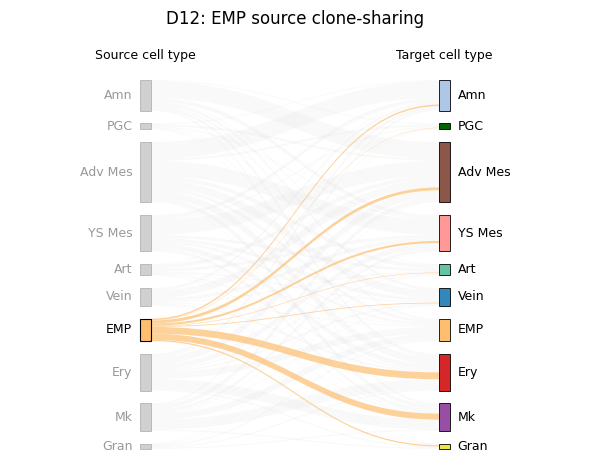

In [ ]:
for day in ["D12"]:
    plot_source_target_alluvial_highlight(
        source_target_df,
        day=day,
        celltype_palette=celltype_palette,
        source_order=source_order,
        target_order=target_order,
        value_key="n_shared_clones",
        min_shared_clones=1,
        highlight_sources=["EMP"],
        figsize=(6.0, 4.8),
        title=f"{day}: EMP source clone-sharing",
        save=fig_dir / f"{day.lower()}_source_target_alluvial_highlight_emp.pdf",
        alpha=0.70,
        background_alpha=0.12,
        label_fontsize=9,
    )

## 11. Stacked barplot

In [ ]:
value_key="n_shared_clones"
normalize=True
exclude_self=True

In [ ]:
from matplotlib.patches import Patch
def plot_source_to_target_stacked_bar(
    df,
    source_celltype,
    days=("D4", "D7", "D12"),
    target_order=None,
    celltype_palette=None,
    value_key="n_shared_clones",
    min_shared_clones=1,
    filter_query=None,
    normalize=True,
    exclude_self=True,
    show_all_targets=False,
    figsize=(4.2, 3.2),
    width=0.72,
    title=None,
    ylabel=None,
    save=None,
    legend=True,
    legend_bbox=(1.02, 1.0),
    default_color="#BDBDBD",
    title_pad=24,
    show_total=True,
):
    """
    Stacked bar plot showing how one source cell type connects to target cell types.

    Each bar = one day.
    Each stacked segment = target cell type.
    Colors = target cell type colors.

    Bar stacking order is flipped so that the visual top-to-bottom order
    matches the legend order.
    """

    df_plot = df.copy()
    df_plot["day"] = df_plot["day"].astype(str)

    if isinstance(days, str):
        days = [days]
    else:
        days = list(days)

    df_plot = df_plot[df_plot["day"].isin([str(d) for d in days])].copy()
    df_plot = df_plot[df_plot["source"] == source_celltype].copy()
    df_plot = df_plot[df_plot["n_shared_clones"] >= min_shared_clones].copy()

    if exclude_self:
        df_plot = df_plot[df_plot["target"] != source_celltype].copy()

    if filter_query is not None:
        df_plot = df_plot.query(filter_query).copy()

    if df_plot.shape[0] == 0:
        print(f"No source-target links found for source = {source_celltype}.")
        return None, None, None

    df_plot = (
        df_plot
        .groupby(["day", "target"], as_index=False)[value_key]
        .sum()
    )

    if target_order is None:
        targets = (
            df_plot
            .groupby("target")[value_key]
            .sum()
            .sort_values(ascending=False)
            .index
            .tolist()
        )
    else:
        if show_all_targets:
            targets = list(target_order)
        else:
            present_targets = set(df_plot["target"])
            targets = [x for x in target_order if x in present_targets]

    plot_mat = (
        df_plot
        .pivot_table(
            index="day",
            columns="target",
            values=value_key,
            aggfunc="sum",
            fill_value=0,
        )
        .reindex(index=[str(d) for d in days])
        .fillna(0)
    )

    for t in targets:
        if t not in plot_mat.columns:
            plot_mat[t] = 0

    plot_mat = plot_mat[targets]

    raw_mat = plot_mat.copy()
    row_sums = plot_mat.sum(axis=1)

    if normalize:
        plot_mat = plot_mat.div(row_sums.replace(0, np.nan), axis=0).fillna(0)

    if celltype_palette is None:
        celltype_palette = {}

    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(len(plot_mat.index))
    bottom = np.zeros(len(plot_mat.index))

    # Important:
    # reverse the plotting order so bar top-to-bottom matches legend top-to-bottom
    plot_targets = list(reversed(targets))

    for target in plot_targets:
        values = plot_mat[target].values
        color = celltype_palette.get(target, default_color)

        ax.bar(
            x,
            values,
            width=width,
            bottom=bottom,
            color=color,
            edgecolor="white",
            linewidth=0.5,
            label=target,
        )

        bottom += values

    ax.set_xticks(x)
    ax.set_xticklabels(plot_mat.index, rotation=0)

    if ylabel is None:
        if normalize:
            ylabel = "Fraction of outgoing shared clones"
        else:
            ylabel = value_key

    ax.set_ylabel(ylabel)

    if title is None:
        title = f"{source_celltype} source to target cell types"

    ax.set_title(title, fontsize=11, pad=title_pad)

    if normalize:
        ax.set_ylim(0, 1.0)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if show_total:
        for i, day in enumerate(plot_mat.index):
            total_v = raw_mat.loc[day].sum()

            if total_v > 0:
                y_text = 1.01 if normalize else total_v * 1.01
                ax.text(
                    i,
                    y_text,
                    f"n={int(total_v)}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )

    if legend:
        legend_handles = [
            Patch(
                facecolor=celltype_palette.get(t, default_color),
                edgecolor="none",
                label=t,
            )
            for t in targets
        ]

        ax.legend(
            handles=legend_handles,
            title="Target",
            frameon=False,
            bbox_to_anchor=legend_bbox,
            loc="upper left",
            borderaxespad=0,
        )

    fig.tight_layout()

    if save is not None:
        fig.savefig(save, bbox_inches="tight", facecolor="white")

    plt.show()

    return fig, ax, plot_mat

/tmp/ipykernel_3531704/382804802.py:190: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


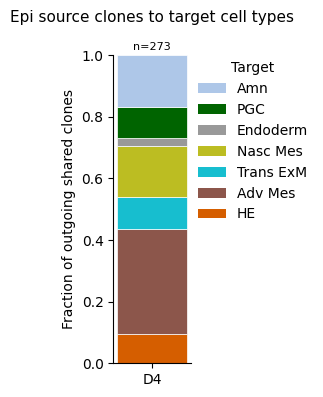

In [ ]:
fig, ax, epi_source_to_target = plot_source_to_target_stacked_bar(
    source_target_df,
    source_celltype="Epi",
    days=["D4"],
    target_order=target_order,
    celltype_palette=celltype_palette,
    value_key="n_shared_clones",
    min_shared_clones=1,
    normalize=True,
    exclude_self=True,
    figsize=(1, 4),
    title="Epi source clones to target cell types",
    save=fig_dir / "source_epi_to_targets_stacked_bar.pdf",
)

/tmp/ipykernel_3531704/382804802.py:190: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


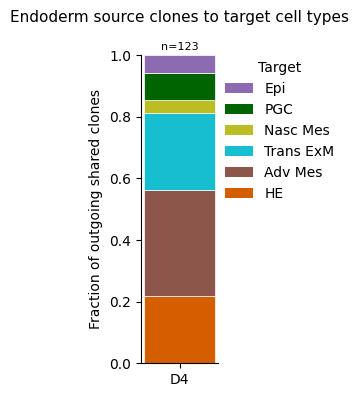

In [ ]:
fig, ax, endoderm_source_to_target = plot_source_to_target_stacked_bar(
    source_target_df,
    source_celltype="Endoderm",
    days=["D4"],
    target_order=target_order,
    celltype_palette=celltype_palette,
    value_key="n_shared_clones",
    min_shared_clones=1,
    normalize=True,
    exclude_self=True,
    figsize=(1, 4),
    title="Endoderm source clones to target cell types",
    save=fig_dir / "source_endoderm_to_targets_stacked_bar.pdf",
)

In [ ]:
def plot_target_from_source_stacked_bar(
    df,
    target_celltype,
    days=("D4", "D7", "D12"),
    source_order=None,
    celltype_palette=None,
    value_key="n_shared_clones",
    min_shared_clones=1,
    filter_query=None,
    normalize=True,
    exclude_self=True,
    show_all_sources=False,
    figsize=(4.2, 3.2),
    width=0.72,
    title=None,
    ylabel=None,
    save=None,
    legend=True,
    legend_bbox=(1.02, 1.0),
    default_color="#BDBDBD",
    title_pad=24,
    show_total=True,
):
    """
    Stacked bar plot showing which source cell types contribute shared clones
    into one selected target cell type.

    Each bar = one day.
    Each stacked segment = source cell type.
    Colors = source cell type colors.

    Bar stacking order is flipped so that the visual top-to-bottom order
    matches the legend order.
    """

    df_plot = df.copy()
    df_plot["day"] = df_plot["day"].astype(str)

    if isinstance(days, str):
        days = [days]
    else:
        days = list(days)

    df_plot = df_plot[df_plot["day"].isin([str(d) for d in days])].copy()
    df_plot = df_plot[df_plot["target"] == target_celltype].copy()
    df_plot = df_plot[df_plot["n_shared_clones"] >= min_shared_clones].copy()

    if exclude_self:
        df_plot = df_plot[df_plot["source"] != target_celltype].copy()

    if filter_query is not None:
        df_plot = df_plot.query(filter_query).copy()

    if df_plot.shape[0] == 0:
        print(f"No source-target links found for target = {target_celltype}.")
        return None, None, None

    df_plot = (
        df_plot
        .groupby(["day", "source"], as_index=False)[value_key]
        .sum()
    )

    if source_order is None:
        sources = (
            df_plot
            .groupby("source")[value_key]
            .sum()
            .sort_values(ascending=False)
            .index
            .tolist()
        )
    else:
        if show_all_sources:
            sources = list(source_order)
        else:
            present_sources = set(df_plot["source"])
            sources = [x for x in source_order if x in present_sources]

    plot_mat = (
        df_plot
        .pivot_table(
            index="day",
            columns="source",
            values=value_key,
            aggfunc="sum",
            fill_value=0,
        )
        .reindex(index=[str(d) for d in days])
        .fillna(0)
    )

    for s in sources:
        if s not in plot_mat.columns:
            plot_mat[s] = 0

    plot_mat = plot_mat[sources]

    raw_mat = plot_mat.copy()
    row_sums = plot_mat.sum(axis=1)

    if normalize:
        plot_mat = plot_mat.div(row_sums.replace(0, np.nan), axis=0).fillna(0)

    if celltype_palette is None:
        celltype_palette = {}

    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(len(plot_mat.index))
    bottom = np.zeros(len(plot_mat.index))

    # Important:
    # reverse the plotting order so bar top-to-bottom matches legend top-to-bottom
    plot_sources = list(reversed(sources))

    for source in plot_sources:
        values = plot_mat[source].values
        color = celltype_palette.get(source, default_color)

        ax.bar(
            x,
            values,
            width=width,
            bottom=bottom,
            color=color,
            edgecolor="white",
            linewidth=0.5,
            label=source,
        )

        bottom += values

    ax.set_xticks(x)
    ax.set_xticklabels(plot_mat.index, rotation=0)

    if ylabel is None:
        if normalize:
            ylabel = "Fraction of incoming shared clones"
        else:
            ylabel = value_key

    ax.set_ylabel(ylabel)

    if title is None:
        title = f"Source clones to {target_celltype}"

    ax.set_title(title, fontsize=11, pad=title_pad)

    if normalize:
        ax.set_ylim(0, 1.0)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if show_total:
        for i, day in enumerate(plot_mat.index):
            total_v = raw_mat.loc[day].sum()

            if total_v > 0:
                y_text = 1.01 if normalize else total_v * 1.01
                ax.text(
                    i,
                    y_text,
                    f"n={int(total_v)}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )

    if legend:
        legend_handles = [
            Patch(
                facecolor=celltype_palette.get(s, default_color),
                edgecolor="none",
                label=s,
            )
            for s in sources
        ]

        ax.legend(
            handles=legend_handles,
            title="Source",
            frameon=False,
            bbox_to_anchor=legend_bbox,
            loc="upper left",
            borderaxespad=0,
        )

    fig.tight_layout()

    if save is not None:
        fig.savefig(save, bbox_inches="tight", facecolor="white")

    plt.show()

    return fig, ax, plot_mat

/tmp/ipykernel_3531704/1025738834.py:190: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


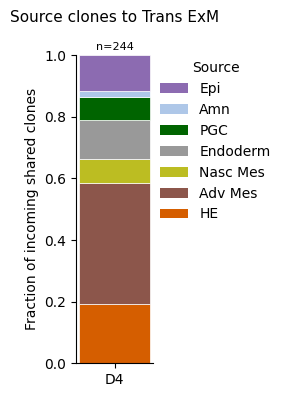

In [ ]:
fig, ax, source_to_transexm = plot_target_from_source_stacked_bar(
    source_target_df,
    target_celltype="Trans ExM",
    days=["D4"],
    source_order=source_order,
    celltype_palette=celltype_palette,
    value_key="n_shared_clones",
    min_shared_clones=1,
    normalize=True,
    exclude_self=True,
    figsize=(1, 4),
    title="Source clones to Trans ExM",
    save=fig_dir / "source_all_to_transexm_stacked_bar.pdf",
)

## load source_target_df

In [ ]:
source_target_df = pd.read_csv(table_dir / "larry_d4_sub_source_target_relationship.csv")

print(source_target_df.shape)
source_target_df.head()

(90, 15)


,day,source,target,n_source_cells,n_target_cells,n_source_clones,n_target_clones,n_shared_clones,source_to_target_fraction,target_from_source_fraction,expected_shared_clones,log2_obs_over_exp,zscore,empirical_p,fdr
0,D4,CDX2+ Hypo,Early Hypo,65,39,57,35,8,0.140351,0.228571,1.082,2.886299,6.987322,0.000999,0.044955
1,D4,Early Hypo,CDX2+ Hypo,39,65,35,57,8,0.228571,0.140351,1.082,2.886299,6.987322,0.000999,0.044955
2,D4,Late Hypo,Trans ExM,45,440,37,303,13,0.351351,0.042904,7.246,0.843255,2.402674,0.018981,0.427073
3,D4,Trans ExM,Late Hypo,440,45,303,37,13,0.042904,0.351351,7.246,0.843255,2.402674,0.018981,0.427073
4,D4,Early Hypo,Late Hypo,39,45,35,37,3,0.085714,0.081081,0.772,1.958290,2.574794,0.046953,0.704296


In [ ]:
celltype_palette = {
    # epithelial / embryo
    "Epi": "#8C6BB1",
    "Epi trans": "#F1A340",
    "PS": "#E377C2",
    "Ambig.": "#7F7F7F",
    "Amn": "#AEC7E8",
    "TE": "#FDB462",
    "PGC": "#006400",

    # endoderm / hypoblast
    "Endoderm": "#999999",
    "Early Hypo": "#CC79A7",
    "Late Hypo": "#0072B2",
    "CDX2+ Hypo": "#E69F00",

    # mesoderm / ExM
    "Nasc Mes": "#BCBD22",
    "Emerg Mes": "#C49C94",
    "Adv Mes": "#8C564B",
    "Trans ExM": "#17BECF",
    "YS Mes": "#FF9896",

    # endothelial
    "HE": "#D55E00",
    "Art": "#66C2A5",
    "Vein": "#3288BD",

    # blood / erythroid / myeloid
    "Blood/Ery": "#D62728",
    "Ery": "#D62728",
    "EMP": "#FDBF6F",
    "Mk": "#984EA3",
    "Gran": "#F0E442",
}

In [ ]:
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_source_to_target_barplot(
    df,
    source_celltype,
    days=("D4", "D7", "D12"),
    target_order=None,
    celltype_palette=None,
    value_key="n_shared_clones",
    min_shared_clones=1,
    filter_query=None,
    normalize=True,
    exclude_self=True,
    show_all_targets=False,
    sort_by_value=True,
    figsize=(5.0, 4.0),
    width=0.72,
    title=None,
    ylabel=None,
    save=None,
    default_color="#BDBDBD",
    title_pad=10,
    show_value_label=True,
    show_total=True,
    rotation=45,
    title_fontsize=11,
    label_fontsize=10,
    tick_fontsize=9,
    bar_label_fontsize=8.5,
):
    """
    Regular barplot showing how one source cell type connects to target cell types.

    Each bar = one target cell type.
    Bar height = target contribution from this source.

    If normalize=True:
        y = value / total outgoing shared clones from source in selected day(s)

    If normalize=False:
        y = summed value_key, usually n_shared_clones

    Colors = target cell type colors.
    """

    df_plot = df.copy()
    df_plot["day"] = df_plot["day"].astype(str)

    if isinstance(days, str):
        days = [days]
    else:
        days = list(days)

    days = [str(d) for d in days]

    df_plot = df_plot[df_plot["day"].isin(days)].copy()
    df_plot = df_plot[df_plot["source"] == source_celltype].copy()
    df_plot = df_plot[df_plot["n_shared_clones"] >= min_shared_clones].copy()

    if exclude_self:
        df_plot = df_plot[df_plot["target"] != source_celltype].copy()

    if filter_query is not None:
        df_plot = df_plot.query(filter_query).copy()

    if df_plot.shape[0] == 0:
        print(f"No source-target links found for source = {source_celltype}.")
        return None, None, None

    # ------------------------------------------------------------
    # Summarize across selected day(s)
    # ------------------------------------------------------------
    df_plot = (
        df_plot
        .groupby("target", as_index=False)
        .agg(
            value=(value_key, "sum"),
            n_shared_clones=("n_shared_clones", "sum"),
        )
    )

    total_value = df_plot["value"].sum()

    if normalize:
        df_plot["plot_value"] = (
            df_plot["value"] / total_value
            if total_value > 0
            else 0
        )
    else:
        df_plot["plot_value"] = df_plot["value"]

    # ------------------------------------------------------------
    # Decide target order
    # ------------------------------------------------------------
    if sort_by_value:
        df_plot = (
            df_plot
            .sort_values("plot_value", ascending=False)
            .reset_index(drop=True)
        )
    else:
        if target_order is None:
            targets = df_plot["target"].tolist()
        else:
            if show_all_targets:
                targets = list(target_order)
            else:
                present_targets = set(df_plot["target"])
                targets = [x for x in target_order if x in present_targets]

        df_plot = (
            df_plot
            .set_index("target")
            .reindex(targets)
            .fillna(0)
            .reset_index()
            .rename(columns={"index": "target"})
        )

    if celltype_palette is None:
        celltype_palette = {}

    colors = [
        celltype_palette.get(t, default_color)
        for t in df_plot["target"]
    ]

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------
    fig, ax = plt.subplots(
        figsize=figsize,
        constrained_layout=False,
    )

    x = np.arange(df_plot.shape[0])

    bars = ax.bar(
        x,
        df_plot["plot_value"].values,
        width=width,
        color=colors,
        edgecolor="black",
        linewidth=0.5,
    )

    # ------------------------------------------------------------
    # Axis labels and ticks
    # ------------------------------------------------------------
    ax.set_xticks(x)
    ax.set_xticklabels(
        df_plot["target"],
        rotation=rotation,
        ha="right" if rotation != 0 else "center",
        fontsize=tick_fontsize,
    )

    ax.tick_params(
        axis="x",
        labelsize=tick_fontsize,
        length=3,
        width=0.8,
    )

    ax.tick_params(
        axis="y",
        labelsize=tick_fontsize,
        length=3,
        width=0.8,
    )

    if ylabel is None:
        if normalize:
            ylabel = "Fraction of outgoing shared clones"
        else:
            ylabel = "Number of shared clones"

    ax.set_ylabel(
        ylabel,
        fontsize=label_fontsize,
        labelpad=8,
    )

    if title is None:
        title = f"{source_celltype} source clones to target cell types"

    ax.set_title(
        title,
        fontsize=title_fontsize,
        pad=title_pad,
        weight="normal",
    )

    # ------------------------------------------------------------
    # Y limit
    # ------------------------------------------------------------
    if normalize:
        y_max = max(df_plot["plot_value"].max() * 1.25, 0.05)
        ax.set_ylim(0, min(y_max, 1.05))
    else:
        y_max = max(df_plot["plot_value"].max() * 1.25, 1)
        ax.set_ylim(0, y_max)

    # ------------------------------------------------------------
    # Clean style
    # ------------------------------------------------------------
    ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    # ------------------------------------------------------------
    # Bar labels
    # ------------------------------------------------------------
    if show_value_label:
        y_upper = ax.get_ylim()[1]

        for bar in bars:
            height = bar.get_height()

            if normalize:
                label = f"{height * 100:.1f}%"
            else:
                label = f"{int(height)}"

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + y_upper * 0.018,
                label,
                ha="center",
                va="bottom",
                fontsize=bar_label_fontsize,
                color="black",
                rotation=0,
            )

    # ------------------------------------------------------------
    # Total label
    # ------------------------------------------------------------
    if show_total and normalize:
        ax.text(
            0.98,
            0.98,
            f"n={int(total_value)}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=bar_label_fontsize,
            color="black",
        )

    # Leave enough room for rotated x labels and y label
    fig.subplots_adjust(
        left=0.20,
        right=0.96,
        bottom=0.32,
        top=0.88,
    )

    if save is not None:
        fig.savefig(
            save,
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
        )
        print(f"Figure saved to {save}")

    plt.show()

    return fig, ax, df_plot

Figure saved to results/figures/2001_lineage_exp_extend/source_epi_to_targets_barplot.pdf


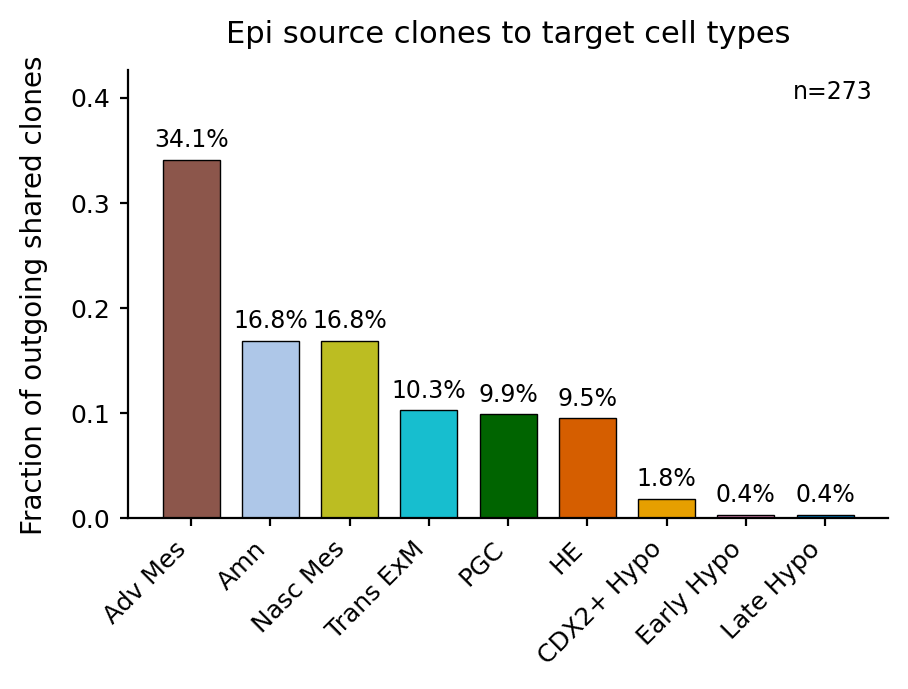

In [ ]:
fig, ax, epi_source_to_target = plot_source_to_target_barplot(
    source_target_df,
    source_celltype="Epi",
    days=["D4"],
    target_order=target_order,
    celltype_palette=celltype_palette,
    value_key="n_shared_clones",
    min_shared_clones=1,
    normalize=True,
    exclude_self=True,
    sort_by_value=True,
    figsize=(5, 4),
    title="Epi source clones to target cell types",
    ylabel="Fraction of outgoing shared clones",
    show_value_label=True,
    show_total=True,
    save=fig_dir / "source_epi_to_targets_barplot.pdf",
)

In [ ]:
def visualize_sources_to_B_from_df(
    source_target_df,
    source_cell_types,
    target_B,
    fig_title=None,
    day=None,
    celltype_palette=None,
    min_source_clones=1,
    figsize=(4.6, 3.8),
    save_path=None,
    dpi=300,
    default_color="#BDBDBD",
    edgecolor="black",
    alpha=0.95,
    show_percentage_label=True,
    show_ratio_label=False,
    title_pad=10,
    xlim=None,
    title_fontsize=11,
    label_fontsize=10,
    tick_fontsize=9,
    bar_label_fontsize=8.5,
):
    """
    Horizontal barplot:
        each bar = one source cell type
        bar value = shared clones with target_B / source clones

    Colors are mapped by source cell type.
    """

    results_df = analyze_multiple_to_B_from_df(
        source_target_df=source_target_df,
        source_cell_types=source_cell_types,
        target_B=target_B,
        day=day,
        min_source_clones=min_source_clones,
        sort=True,
        verbose=True,
    )

    if results_df.empty:
        raise ValueError("No rows left after filtering.")

    if celltype_palette is None:
        celltype_palette = {}

    sources = results_df["Source"].tolist()
    percentages = results_df["Percentage (shared/source)"].values

    colors = [
        celltype_palette.get(source, default_color)
        for source in sources
    ]

    fig, ax = plt.subplots(
        figsize=figsize,
        constrained_layout=False,
    )

    y_pos = np.arange(len(sources))

    bars = ax.barh(
        y_pos,
        percentages,
        color=colors,
        edgecolor=edgecolor,
        linewidth=0.5,
        alpha=alpha,
        height=0.72,
    )

    # ------------------------------------------------------------
    # Axis ticks and labels
    # ------------------------------------------------------------
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sources, fontsize=tick_fontsize)
    ax.invert_yaxis()

    ax.tick_params(
        axis="x",
        labelsize=tick_fontsize,
        length=3,
        width=0.8,
    )

    ax.tick_params(
        axis="y",
        labelsize=tick_fontsize,
        length=0,
    )

    # Shorter x-axis label to avoid clipping
    ax.set_xlabel(
        f"Source clones shared with {target_B} (%)",
        fontsize=label_fontsize,
        labelpad=8,
    )

    if xlim is None:
        max_perc = percentages.max()
        x_max = max(max_perc * 1.35, 5)
        ax.set_xlim(0, x_max)
    else:
        ax.set_xlim(xlim)

    if fig_title is None:
        if day is None:
            fig_title = f"Source clones to {target_B}"
        elif isinstance(day, str):
            fig_title = f"{day} source clones to {target_B}"
        else:
            fig_title = f"Source clones to {target_B}"

    ax.set_title(
        fig_title,
        fontsize=title_fontsize,
        pad=title_pad,
        weight="normal",
    )

    # ------------------------------------------------------------
    # Clean style
    # ------------------------------------------------------------
    ax.grid(False)

    # ax.spines["top"].set_visible(False)
    # ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    # ------------------------------------------------------------
    # Add bar labels
    # ------------------------------------------------------------
    if show_percentage_label or show_ratio_label:
        x_upper = ax.get_xlim()[1]

        for bar, (_, row) in zip(bars, results_df.iterrows()):
            width = bar.get_width()
            y = bar.get_y() + bar.get_height() / 2

            label_parts = []

            if show_percentage_label:
                label_parts.append(f"{width:.1f}%")

            if show_ratio_label:
                label_parts.append(
                    f"({int(row['Shared Clones'])}/"
                    f"{int(row['Source Clones'])})"
                )

            label = " ".join(label_parts)

            ax.text(
                width + x_upper * 0.018,
                y,
                label,
                ha="left",
                va="center",
                fontsize=bar_label_fontsize,
                color="black",
                fontweight="normal",
            )

    # More space for y labels and x-axis label
    fig.subplots_adjust(
        left=0.30,
        right=0.96,
        bottom=0.18,
        top=0.88,
    )

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=dpi,
            bbox_inches="tight",
            facecolor="white",
        )
        print(f"Figure saved to {save_path}")

    plt.show()

    return results_df

In [ ]:
# ------------------------------------------------------------------
# Source clone check from source_target_df
# ------------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def analyze_multiple_to_B_from_df(
    source_target_df,
    source_cell_types,
    target_B,
    day=None,
    min_source_clones=1,
    sort=True,
    verbose=True,
):
    """
    Analyze how many clones from different source populations go to target_B.

    Input source_target_df should contain columns:
        source
        target
        n_source_clones
        n_target_clones
        n_shared_clones
        source_to_target_fraction
        day, optional but recommended

    Metric:
        percentage = n_shared_clones / n_source_clones * 100
    """

    df = source_target_df.copy()

    if day is not None:
        if isinstance(day, str):
            day = [day]
        day = [str(x) for x in day]
        df["day"] = df["day"].astype(str)
        df = df[df["day"].isin(day)].copy()

    df = df[
        (df["source"].isin(source_cell_types)) &
        (df["target"] == target_B)
    ].copy()

    if df.empty:
        raise ValueError(
            f"No source-target rows found for target_B={target_B} "
            f"and source_cell_types={source_cell_types}."
        )

    # If multiple days are selected, summarize across days.
    # n_source_clones and n_target_clones are summed here for simplicity.
    # For single-day usage, this preserves the original values.
    results_df = (
        df
        .groupby(["source", "target"], as_index=False)
        .agg(
            n_source_clones=("n_source_clones", "sum"),
            n_target_clones=("n_target_clones", "sum"),
            n_shared_clones=("n_shared_clones", "sum"),
        )
    )

    results_df["percentage"] = (
        results_df["n_shared_clones"] /
        results_df["n_source_clones"].replace(0, np.nan) *
        100
    ).fillna(0)

    results_df = results_df[
        results_df["n_source_clones"] >= min_source_clones
    ].copy()

    # Keep the old column names so your downstream code is familiar
    results_df = results_df.rename(
        columns={
            "source": "Source",
            "target": "Target",
            "n_source_clones": "Source Clones",
            "n_target_clones": "Target Clones",
            "n_shared_clones": "Shared Clones",
            "percentage": "Percentage (shared/source)",
        }
    )

    results_df["Ratio (shared/source)"] = (
        results_df["Shared Clones"].astype(int).astype(str) +
        "/" +
        results_df["Source Clones"].astype(int).astype(str)
    )

    # Make sure all requested source_cell_types appear if present in df.
    # Missing source-target pairs are not added automatically.
    if sort:
        results_df = results_df.sort_values(
            "Percentage (shared/source)",
            ascending=False,
        ).reset_index(drop=True)

    if verbose:
        target_clones = (
            results_df["Target Clones"].iloc[0]
            if len(results_df) > 0
            else np.nan
        )

        print(f"ANALYSIS: How many clones of different sources go to {target_B}?")
        print("=" * 70)
        print(f"Target cell type: {target_B} ({int(target_clones)} clones)")
        print("Metric: shared clones between source and target / source clones")
        print("=" * 70)

        display_df = results_df[
            [
                "Source",
                "Source Clones",
                "Shared Clones",
                "Percentage (shared/source)",
                "Ratio (shared/source)",
            ]
        ].copy()

        display_df["Percentage (shared/source)"] = (
            display_df["Percentage (shared/source)"].round(2)
        )

        print("\nRESULTS sorted by percentage, highest first:")
        print("=" * 80)
        print(display_df.to_string(index=False))

    return results_df

ANALYSIS: How many clones of different sources go to Trans ExM?
Target cell type: Trans ExM (303 clones)
Metric: shared clones between source and target / source clones

RESULTS sorted by percentage, highest first:
    Source  Source Clones  Shared Clones  Percentage (shared/source) Ratio (shared/source)
 Late Hypo             37             13                       35.14                 13/37
Early Hypo             35             10                       28.57                 10/35
CDX2+ Hypo             57             13                       22.81                 13/57
        HE            331             47                       14.20                47/331
   Adv Mes            796             96                       12.06                96/796
  Nasc Mes            214             19                        8.88                19/214
       PGC            214             18                        8.41                18/214
       Epi           1143             28                 

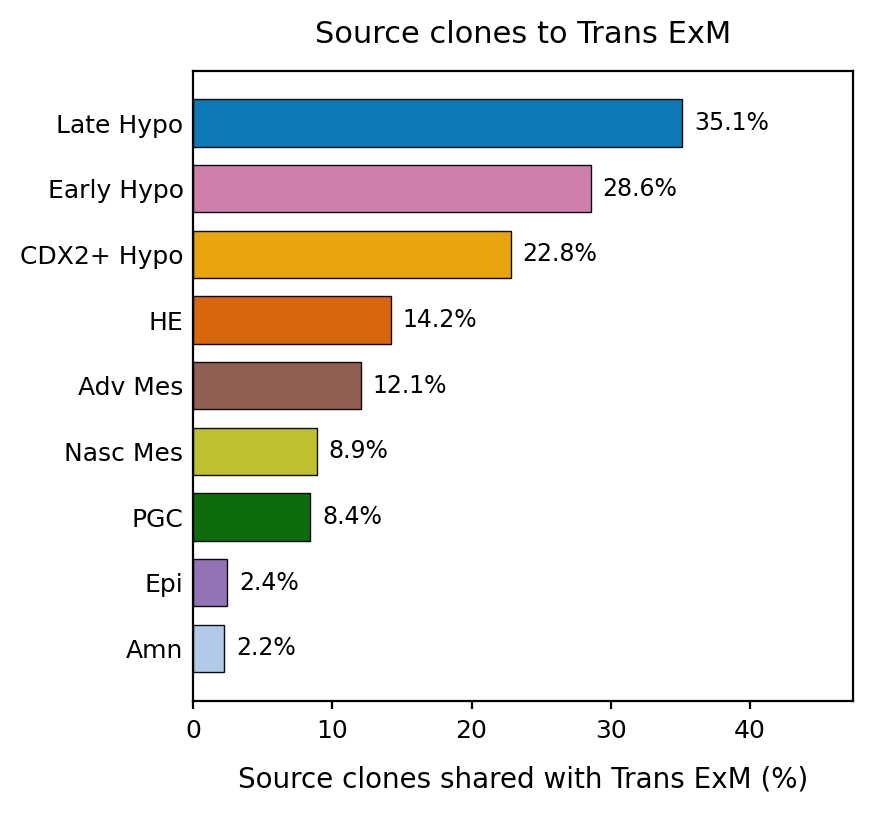

In [ ]:
results_df = visualize_sources_to_B_from_df(
    source_target_df=source_target_df,
    source_cell_types=source_order,
    target_B="Trans ExM",
    day="D4",
    celltype_palette=celltype_palette,
    min_source_clones=3,
    figsize=(5, 4.5),
    fig_title="Source clones to Trans ExM",
    show_percentage_label=True,
    show_ratio_label=False,
    save_path=fig_dir / "source_all_to_transexm_barplot.pdf",
)

ANALYSIS: How many clones of different sources go to Trans ExM?
Target cell type: Trans ExM (303 clones)
Metric: shared clones between source and target / source clones

RESULTS sorted by percentage, highest first:
    Source  Source Clones  Shared Clones  Percentage (shared/source) Ratio (shared/source)
 Late Hypo             37             13                       35.14                 13/37
Early Hypo             35             10                       28.57                 10/35
CDX2+ Hypo             57             13                       22.81                 13/57
       Epi           1143             28                        2.45               28/1143
Figure saved to results/figures/2001_lineage_exp_extend/source_endo_sub_to_transexm_barplot.pdf


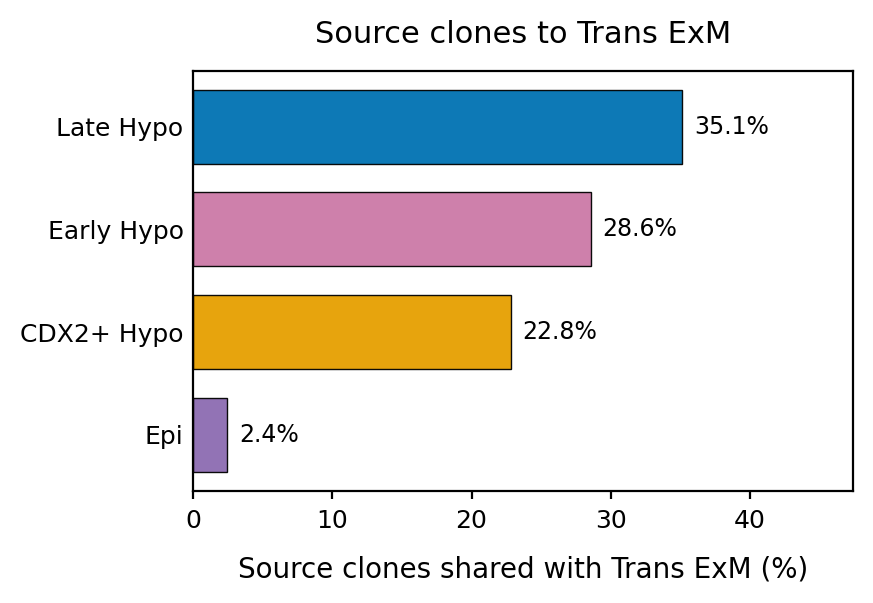

In [ ]:
results_df = visualize_sources_to_B_from_df(
    source_target_df=source_target_df,
    source_cell_types=['Early Hypo', 'Late Hypo', 'CDX2+ Hypo', 'Epi'],
    target_B="Trans ExM",
    day="D4",
    celltype_palette=celltype_palette,
    min_source_clones=3,
    figsize=(5, 3),
    fig_title="Source clones to Trans ExM",
    show_percentage_label=True,
    show_ratio_label=False,
    save_path=fig_dir / "source_endo_sub_to_transexm_barplot.pdf",
)

In [ ]:
def visualize_sources_to_B_from_df_vertical(
    source_target_df,
    source_cell_types,
    target_B,
    fig_title=None,
    day=None,
    celltype_palette=None,
    min_source_clones=1,
    figsize=(5.2, 4.0),
    save_path=None,
    dpi=300,
    default_color="#BDBDBD",
    edgecolor="black",
    alpha=0.95,
    show_percentage_label=True,
    show_ratio_label=False,
    title_pad=10,
    ylim=None,
    rotation=45,
    title_fontsize=11,
    label_fontsize=10,
    tick_fontsize=9,
    bar_label_fontsize=8.5,
):
    """
    Vertical barplot:
        each bar = one source cell type
        bar value = shared clones with target_B / source clones

    Colors are mapped by source cell type.
    """

    results_df = analyze_multiple_to_B_from_df(
        source_target_df=source_target_df,
        source_cell_types=source_cell_types,
        target_B=target_B,
        day=day,
        min_source_clones=min_source_clones,
        sort=True,
        verbose=True,
    )

    if results_df.empty:
        raise ValueError("No rows left after filtering.")

    if celltype_palette is None:
        celltype_palette = {}

    sources = results_df["Source"].tolist()
    percentages = results_df["Percentage (shared/source)"].values

    colors = [
        celltype_palette.get(source, default_color)
        for source in sources
    ]

    fig, ax = plt.subplots(
        figsize=figsize,
        constrained_layout=False,
    )

    x = np.arange(len(sources))

    bars = ax.bar(
        x,
        percentages,
        color=colors,
        edgecolor=edgecolor,
        linewidth=0.5,
        alpha=alpha,
        width=0.72,
    )

    # ------------------------------------------------------------
    # Axis ticks and labels
    # ------------------------------------------------------------
    ax.set_xticks(x)
    ax.set_xticklabels(
        sources,
        rotation=rotation,
        ha="right" if rotation != 0 else "center",
        fontsize=tick_fontsize,
    )

    ax.tick_params(
        axis="x",
        labelsize=tick_fontsize,
        length=3,
        width=0.8,
    )

    ax.tick_params(
        axis="y",
        labelsize=tick_fontsize,
        length=3,
        width=0.8,
    )

    ax.set_ylabel(
        f"Source clones shared with {target_B} (%)",
        fontsize=label_fontsize,
        labelpad=8,
    )

    if ylim is None:
        max_perc = percentages.max()
        y_max = max(max_perc * 1.28, 5)
        ax.set_ylim(0, y_max)
    else:
        ax.set_ylim(ylim)

    if fig_title is None:
        if day is None:
            fig_title = f"Source clones to {target_B}"
        elif isinstance(day, str):
            fig_title = f"{day} source clones to {target_B}"
        else:
            fig_title = f"Source clones to {target_B}"

    ax.set_title(
        fig_title,
        fontsize=title_fontsize,
        pad=title_pad,
        weight="normal",
    )

    # ------------------------------------------------------------
    # Clean style
    # ------------------------------------------------------------
    ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    # ------------------------------------------------------------
    # Add bar labels
    # ------------------------------------------------------------
    if show_percentage_label or show_ratio_label:
        y_upper = ax.get_ylim()[1]

        for bar, (_, row) in zip(bars, results_df.iterrows()):
            height = bar.get_height()

            label_parts = []

            if show_percentage_label:
                label_parts.append(f"{height:.1f}%")

            if show_ratio_label:
                label_parts.append(
                    f"({int(row['Shared Clones'])}/"
                    f"{int(row['Source Clones'])})"
                )

            label = " ".join(label_parts)

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + y_upper * 0.018,
                label,
                ha="center",
                va="bottom",
                fontsize=bar_label_fontsize,
                color="black",
                rotation=0,
            )

    # Leave enough space for rotated x labels and y label
    fig.subplots_adjust(
        left=0.18,
        right=0.96,
        bottom=0.32,
        top=0.88,
    )

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=dpi,
            bbox_inches="tight",
            facecolor="white",
        )
        print(f"Figure saved to {save_path}")

    plt.show()

    return results_df

ANALYSIS: How many clones of different sources go to Trans ExM?
Target cell type: Trans ExM (303 clones)
Metric: shared clones between source and target / source clones

RESULTS sorted by percentage, highest first:
    Source  Source Clones  Shared Clones  Percentage (shared/source) Ratio (shared/source)
CDX2+ Hypo             57             13                       22.81                 13/57
       Epi           1143             28                        2.45               28/1143
Figure saved to results/figures/2001_lineage_exp_extend/source_cdx2_epi_to_transexm_barplot.pdf


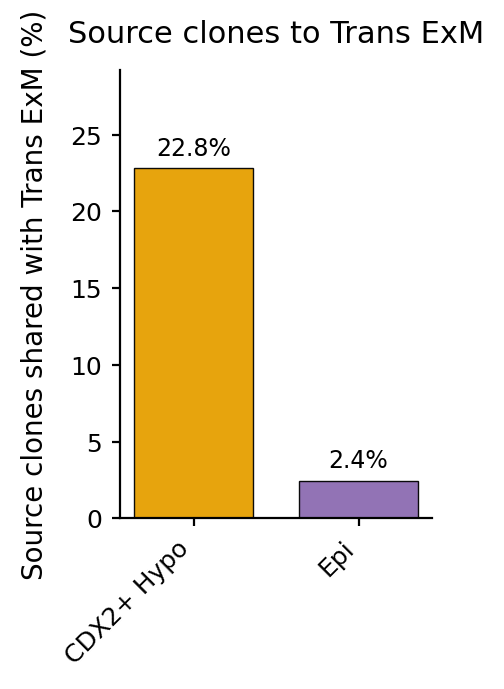

In [ ]:
results_df = visualize_sources_to_B_from_df_vertical(
    source_target_df=source_target_df,
    source_cell_types=['CDX2+ Hypo', 'Epi'],
    target_B="Trans ExM",
    day="D4",
    celltype_palette=celltype_palette,
    min_source_clones=3,
    figsize=(2, 4),
    fig_title="Source clones to Trans ExM",
    show_percentage_label=True,
    show_ratio_label=False,
    save_path=fig_dir / "source_cdx2_epi_to_transexm_barplot.pdf",
)

ANALYSIS: How many clones of different sources go to Trans ExM?
Target cell type: Trans ExM (303 clones)
Metric: shared clones between source and target / source clones

RESULTS sorted by percentage, highest first:
    Source  Source Clones  Shared Clones  Percentage (shared/source) Ratio (shared/source)
 Late Hypo             37             13                       35.14                 13/37
Early Hypo             35             10                       28.57                 10/35
CDX2+ Hypo             57             13                       22.81                 13/57
       Epi           1143             28                        2.45               28/1143
Figure saved to results/figures/2001_lineage_exp_extend/source_endo_sub_epi_to_transexm_barplot_vertical.pdf


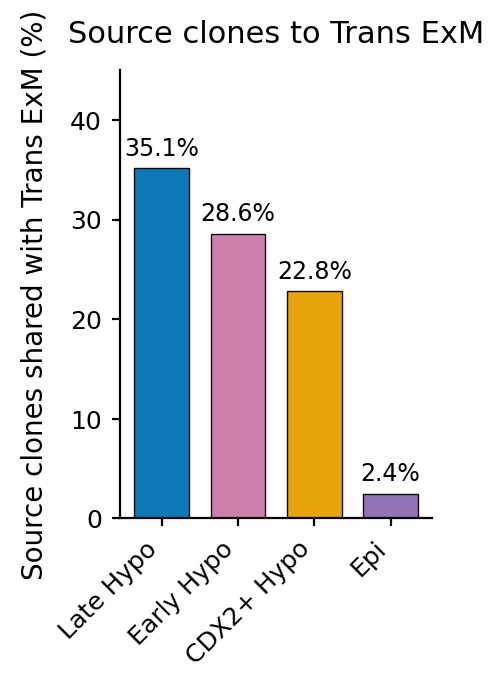

In [ ]:
results_df = visualize_sources_to_B_from_df_vertical(
    source_target_df=source_target_df,
    source_cell_types=['Early Hypo', 'Late Hypo', 'CDX2+ Hypo', 'Epi'],
    target_B="Trans ExM",
    day="D4",
    celltype_palette=celltype_palette,
    min_source_clones=3,
    figsize=(2, 4),
    fig_title="Source clones to Trans ExM",
    show_percentage_label=True,
    show_ratio_label=False,
    save_path=fig_dir / "source_endo_sub_epi_to_transexm_barplot_vertical.pdf",
)